# Prova - Classificador supervisionado


**Repositório do projeto no GitHub:** https://github.com/lip3bit/classificador_projeto

O repositório contém este notebook já executado, o `README.md` com instruções de reprodução e o `requirements.txt`.

### 1) Qual a base escolhida?

**Forest Covertype** (UCI Machine Learning Repository: https://archive.ics.uci.edu/ml/datasets/Covertype), carregada com `sklearn.datasets.fetch_covtype`.

Cada amostra é uma célula de terreno de 30 m × 30 m da Roosevelt National Forest (Colorado, EUA), descrita só por variáveis cartográficas: altitude, orientação, inclinação, distâncias até água, estradas e focos de incêndio, sombreamento, área selvagem e tipo de solo. O objetivo é prever o **tipo de cobertura florestal** predominante na célula, entre **7 classes**.

- 581.012 amostras
- 54 features (10 numéricas + 44 binárias)
- Problema de **classificação multiclasse supervisionada** com classes desbalanceadas

### 2) **(10%)** Pré-processamento: entendimento do conjunto de dados
- Quais são minhas features?
- Quais são minhas classes?
- Como estão distribuidas minhas classes?
- Checagem se os valores estão dentro de um limite permitido ou razoável.
- Tratamento de valores ausentes por eliminação ou substituição.
- Conversão do tipo de dados.


In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import (train_test_split, GridSearchCV, PredefinedSplit, StratifiedKFold,
                                     cross_validate, learning_curve)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

#### 2.1) Carregamento dos dados

In [2]:
dados = fetch_covtype(as_frame=True)
df = dados.frame.copy()
print(f'Formato: {df.shape[0]:,} linhas x {df.shape[1]} colunas (54 features + 1 alvo)')
df.head()

Formato: 581,012 linhas x 55 colunas (54 features + 1 alvo)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness_Area_0,Wilderness_Area_1,Wilderness_Area_2,Wilderness_Area_3,Soil_Type_0,Soil_Type_1,Soil_Type_2,Soil_Type_3,Soil_Type_4,Soil_Type_5,Soil_Type_6,Soil_Type_7,Soil_Type_8,Soil_Type_9,Soil_Type_10,Soil_Type_11,Soil_Type_12,Soil_Type_13,Soil_Type_14,Soil_Type_15,Soil_Type_16,Soil_Type_17,Soil_Type_18,Soil_Type_19,Soil_Type_20,Soil_Type_21,Soil_Type_22,Soil_Type_23,Soil_Type_24,Soil_Type_25,Soil_Type_26,Soil_Type_27,Soil_Type_28,Soil_Type_29,Soil_Type_30,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


#### 2.2) Quais são minhas features?

| Grupo | Colunas | Descrição |
|---|---|---|
| Numéricas (10) | `Elevation` | Altitude (m) |
| | `Aspect` | Orientação da encosta, azimute em graus (0–360) |
| | `Slope` | Inclinação (graus) |
| | `Horizontal_Distance_To_Hydrology` | Distância horizontal até a água mais próxima (m) |
| | `Vertical_Distance_To_Hydrology` | Distância vertical até a água mais próxima (m); negativa quando a célula está abaixo da água |
| | `Horizontal_Distance_To_Roadways` | Distância horizontal até a estrada mais próxima (m) |
| | `Hillshade_9am`, `Hillshade_Noon`, `Hillshade_3pm` | Índice de sombreamento (0–255) às 9h, 12h e 15h no solstício de verão |
| | `Horizontal_Distance_To_Fire_Points` | Distância horizontal até o foco de incêndio mais próximo (m) |
| Binárias (4) | `Wilderness_Area_0..3` | One-hot da área selvagem: 0 = Rawah, 1 = Neota, 2 = Comanche Peak, 3 = Cache la Poudre |
| Binárias (40) | `Soil_Type_0..39` | One-hot do tipo de solo (código ELU do USFS) |

In [3]:
ALVO = 'Cover_Type'
COLS_NUM = list(df.columns[:10])
COLS_WILD = [c for c in df.columns if c.startswith('Wilderness_Area')]
COLS_SOIL = [c for c in df.columns if c.startswith('Soil_Type')]

print(f'Numéricas: {len(COLS_NUM)} | Área selvagem: {len(COLS_WILD)} | Tipo de solo: {len(COLS_SOIL)}')
print('\nTipos de dado como vieram do sklearn:')
print(df.dtypes.value_counts().to_string())

Numéricas: 10 | Área selvagem: 4 | Tipo de solo: 40

Tipos de dado como vieram do sklearn:
float64    54
int32       1


#### 2.3) Quais são minhas classes e como estão distribuídas?

,classe,amostras,%
Cover_Type,,,
1,Spruce/Fir,211840,36.46
2,Lodgepole Pine,283301,48.76
3,Ponderosa Pine,35754,6.15
4,Cottonwood/Willow,2747,0.47
5,Aspen,9493,1.63
6,Douglas-fir,17367,2.99
7,Krummholz,20510,3.53


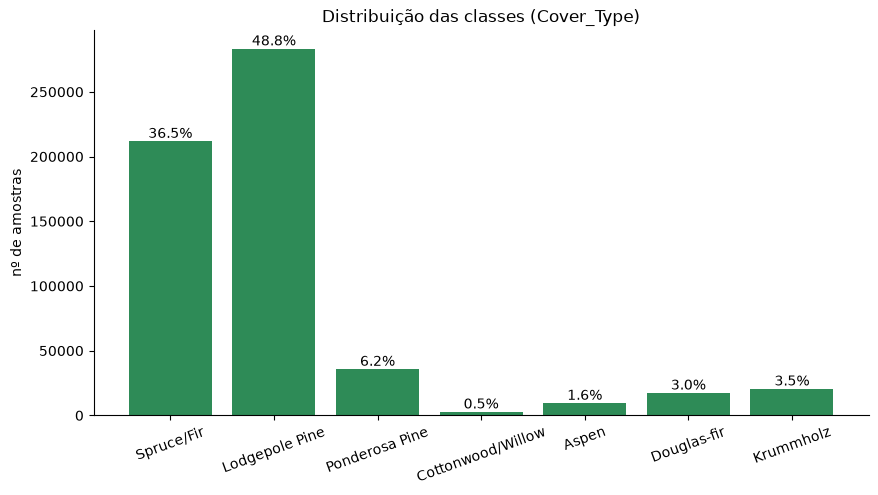

A maior classe tem 103x mais amostras que a menor.


In [4]:
NOMES_CLASSES = {1: 'Spruce/Fir', 2: 'Lodgepole Pine', 3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
                 5: 'Aspen', 6: 'Douglas-fir', 7: 'Krummholz'}
ROTULOS = list(NOMES_CLASSES.values())

dist = df[ALVO].value_counts().sort_index()
tabela_classes = pd.DataFrame({'classe': dist.index.map(NOMES_CLASSES),
                               'amostras': dist.values,
                               '%': (100 * dist / dist.sum()).round(2).values}, index=dist.index)
display(tabela_classes)

fig, ax = plt.subplots()
barras = ax.bar(tabela_classes['classe'], tabela_classes['amostras'], color='seagreen')
for barra, pct in zip(barras, tabela_classes['%']):
    ax.text(barra.get_x() + barra.get_width() / 2, barra.get_height(), f'{pct:.1f}%', ha='center', va='bottom')
ax.set_title('Distribuição das classes (Cover_Type)')
ax.set_ylabel('nº de amostras')
plt.xticks(rotation=20)
plt.show()

print(f'A maior classe tem {dist.max() / dist.min():.0f}x mais amostras que a menor.')

As classes são **muito desbalanceadas**: Lodgepole Pine e Spruce/Fir somam cerca de 85% da base, e Cottonwood/Willow tem menos de 0,5%. Isso traz três consequências para o projeto:

1. As divisões treino/validação/teste serão **estratificadas** para manter as proporções.
2. A **acurácia sozinha engana**: um modelo que só responde "Lodgepole Pine" já acerta cerca de 49%. Por isso a métrica principal será o **F1-macro**, que pesa todas as classes igualmente, acompanhado de acurácia e *balanced accuracy*.
3. Vale testar `class_weight='balanced'` no tunning.

#### 2.4) Checagem se os valores estão dentro de um limite permitido ou razoável

In [5]:
LIMITES = {
    'Elevation': (0, 4400, 'altitude em m; o ponto mais alto do Colorado tem ~4.400 m'),
    'Aspect': (0, 360, 'azimute em graus'),
    'Slope': (0, 90, 'inclinação em graus'),
    'Horizontal_Distance_To_Hydrology': (0, np.inf, 'distância não pode ser negativa'),
    'Vertical_Distance_To_Hydrology': (-np.inf, np.inf, 'pode ser negativa (célula abaixo da água)'),
    'Horizontal_Distance_To_Roadways': (0, np.inf, 'distância não pode ser negativa'),
    'Hillshade_9am': (0, 255, 'índice de 8 bits'),
    'Hillshade_Noon': (0, 255, 'índice de 8 bits'),
    'Hillshade_3pm': (0, 255, 'índice de 8 bits'),
    'Horizontal_Distance_To_Fire_Points': (0, np.inf, 'distância não pode ser negativa'),
}

checagem = df[COLS_NUM].describe().T[['min', 'mean', 'max']]
checagem['limite mín.'] = [LIMITES[c][0] for c in checagem.index]
checagem['limite máx.'] = [LIMITES[c][1] for c in checagem.index]
checagem['dentro do limite?'] = (checagem['min'] >= checagem['limite mín.']) & (checagem['max'] <= checagem['limite máx.'])
checagem['justificativa'] = [LIMITES[c][2] for c in checagem.index]
display(checagem.round(1))

,min,mean,max,limite mín.,limite máx.,dentro do limite?,justificativa
Elevation,1859.0,2959.4,3858.0,0.0,4400.0,True,altitude em m; o ponto mais alto do Colorado t...
Aspect,0.0,155.7,360.0,0.0,360.0,True,azimute em graus
Slope,0.0,14.1,66.0,0.0,90.0,True,inclinação em graus
Horizontal_Distance_To_Hydrology,0.0,269.4,1397.0,0.0,inf,True,distância não pode ser negativa
Vertical_Distance_To_Hydrology,-173.0,46.4,601.0,-inf,inf,True,pode ser negativa (célula abaixo da água)
Horizontal_Distance_To_Roadways,0.0,2350.1,7117.0,0.0,inf,True,distância não pode ser negativa
Hillshade_9am,0.0,212.1,254.0,0.0,255.0,True,índice de 8 bits
Hillshade_Noon,0.0,223.3,254.0,0.0,255.0,True,índice de 8 bits
Hillshade_3pm,0.0,142.5,254.0,0.0,255.0,True,índice de 8 bits
Horizontal_Distance_To_Fire_Points,0.0,1980.3,7173.0,0.0,inf,True,distância não pode ser negativa


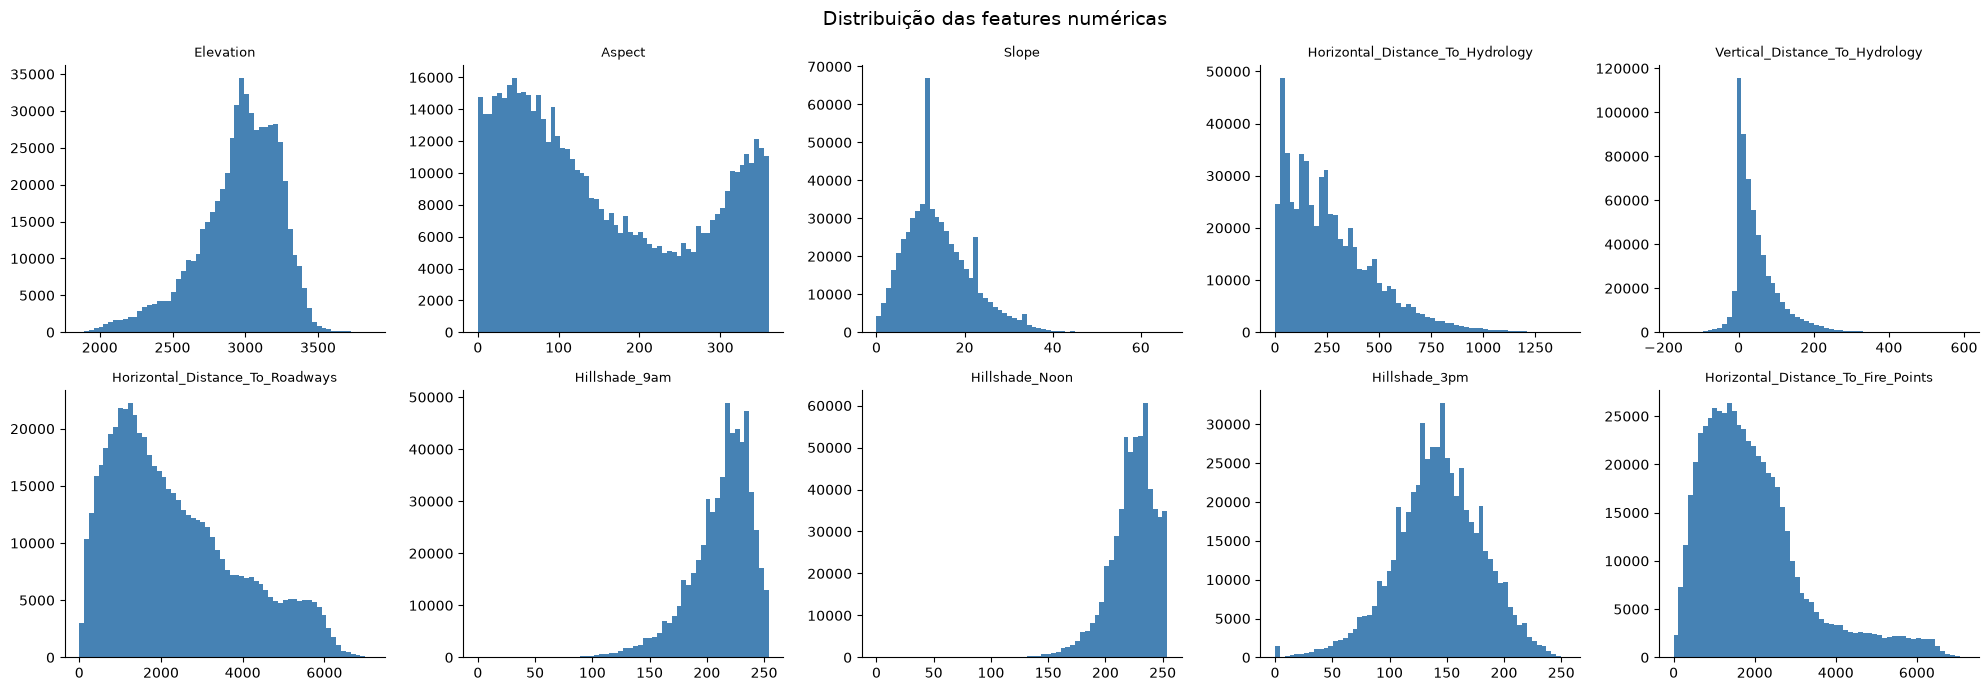

In [6]:
fig, eixos = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(eixos.ravel(), COLS_NUM):
    ax.hist(df[col], bins=60, color='steelblue')
    ax.set_title(col, fontsize=9)
fig.suptitle('Distribuição das features numéricas', fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# Casos de borda que merecem atenção
print(f"Aspect == 360: {(df['Aspect'] == 360).sum()} linhas (360° e 0° são a mesma direção: o Norte)")
for col in ['Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm']:
    print(f'{col} == 0: {(df[col] == 0).sum()} linhas')

# One-hot consistente: cada linha precisa ter exatamente 1 área selvagem e 1 tipo de solo
print('\nSoma das colunas de área selvagem por linha:', df[COLS_WILD].sum(axis=1).value_counts().to_dict())
print('Soma das colunas de tipo de solo por linha:  ', df[COLS_SOIL].sum(axis=1).value_counts().to_dict())

print(f'\nLinhas duplicadas: {df.duplicated().sum()}')

Aspect == 360: 51 linhas (360° e 0° são a mesma direção: o Norte)
Hillshade_9am == 0: 13 linhas
Hillshade_Noon == 0: 5 linhas
Hillshade_3pm == 0: 1338 linhas

Soma das colunas de área selvagem por linha: {1.0: 581012}


Soma das colunas de tipo de solo por linha:   {1.0: 581012}



Linhas duplicadas: 0


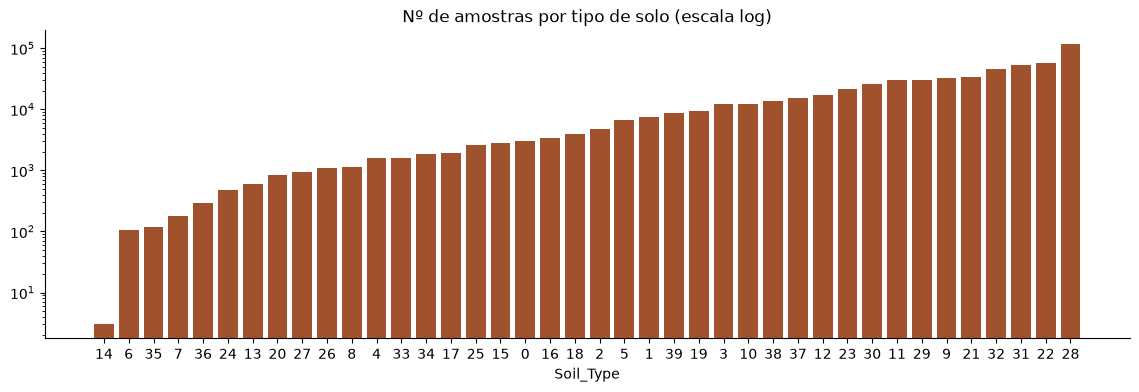

Tipos de solo com menos de 200 amostras:
Soil_Type_14      3
Soil_Type_6     105
Soil_Type_35    119
Soil_Type_7     179


In [8]:
# Tipos de solo quase vazios: colunas que quase nunca valem 1
contagem_solo = df[COLS_SOIL].sum().sort_values()
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(contagem_solo.index.str.replace('Soil_Type_', ''), contagem_solo.values, color='sienna')
ax.set_yscale('log')
ax.set_title('Nº de amostras por tipo de solo (escala log)')
ax.set_xlabel('Soil_Type')
plt.show()
print('Tipos de solo com menos de 200 amostras:')
print(contagem_solo[contagem_solo < 200].astype(int).to_string())

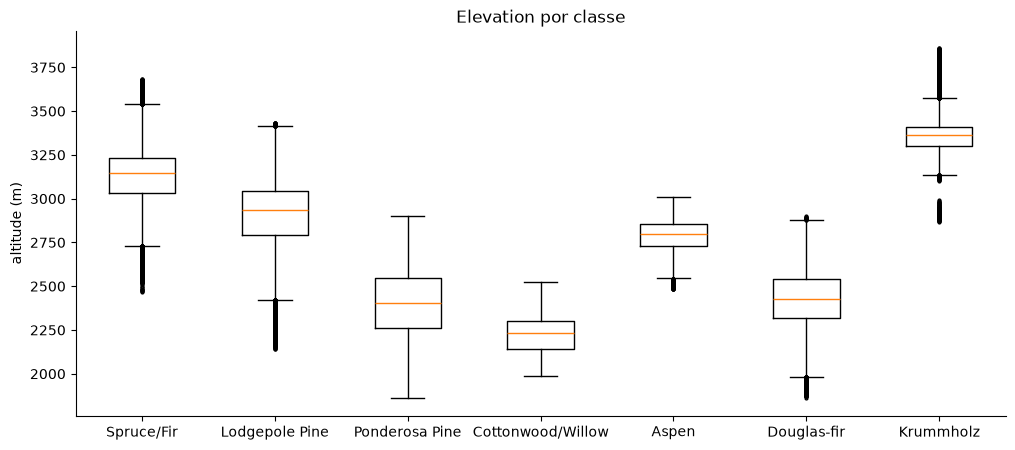

In [9]:
# A altitude separa bem as classes: os boxplots mostram faixas típicas de cada espécie
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot([df.loc[df[ALVO] == k, 'Elevation'] for k in NOMES_CLASSES], tick_labels=ROTULOS, flierprops={'markersize': 2})
ax.set_title('Elevation por classe')
ax.set_ylabel('altitude (m)')
plt.show()

**Resultado da checagem:**
- Todas as features numéricas estão dentro dos limites físicos esperados. Nenhum valor impossível foi encontrado (por exemplo, distância horizontal negativa ou sombreamento acima de 255).
- `Vertical_Distance_To_Hydrology` negativa **não é erro**: significa que a célula está abaixo do nível da água mais próxima.
- `Aspect = 360` equivale a `Aspect = 0` (Norte). Esses valores serão convertidos para 0 para que a mesma direção não tenha dois códigos.
- Zeros de `Hillshade_3pm` são plausíveis: encostas voltadas para leste ficam totalmente sombreadas à tarde. Eles foram **mantidos**.
- O one-hot é consistente: toda linha tem exatamente 1 área selvagem e 1 tipo de solo. Não há linhas duplicadas.
- Os pontos fora dos bigodes nos boxplots são valores reais do terreno, e não erros de medição. Por isso **não foram removidos**.
- Alguns tipos de solo quase não aparecem (`Soil_Type_14` tem só 3 amostras). Isso motiva a redução de dimensionalidade testada nos modelos.

#### 2.5) Tratamento de valores ausentes

In [10]:
ausentes = df.isna().sum()
print(f'Valores ausentes (NaN) na base inteira: {ausentes.sum()}')
print(f'Valores infinitos na base inteira:      {np.isinf(df.to_numpy()).sum()}')

Valores ausentes (NaN) na base inteira: 0
Valores infinitos na base inteira:      0


A base **não tem valores ausentes nem infinitos**, então não é preciso eliminar linhas nem imputar valores.

Se houvesse, a estratégia seria:
- **Eliminar** a linha, se o ausente estivesse no alvo.
- **Substituir** pela mediana nas features numéricas, por ser robusta a outliers.
- **Substituir** pela moda nas binárias.

Em ambos os casos, a mediana e a moda seriam calculadas **somente no conjunto de treino**, para não vazar informação do teste.

#### 2.6) Conversão do tipo de dados

In [11]:
memoria_antes = df.memory_usage(deep=True).sum() / 1e6

# Correção de Aspect: 360° -> 0°
df.loc[df['Aspect'] == 360, 'Aspect'] = 0

# Todas as features vêm como float64, mas são inteiras. Conferindo antes de converter:
assert (df[COLS_NUM + COLS_WILD + COLS_SOIL] % 1 == 0).all().all()

for col in COLS_NUM:
    df[col] = pd.to_numeric(df[col], downcast='integer')        # int16 (cabe em ±32.767)
for col in COLS_WILD + COLS_SOIL:
    df[col] = df[col].astype('uint8')                            # binárias 0/1
df[ALVO] = df[ALVO].astype('int8')

memoria_depois = df.memory_usage(deep=True).sum() / 1e6
print(f'Memória: {memoria_antes:.0f} MB -> {memoria_depois:.0f} MB')
print(df.dtypes.value_counts().to_string())

Memória: 253 MB -> 37 MB
uint8    44
int16     9
int8      2


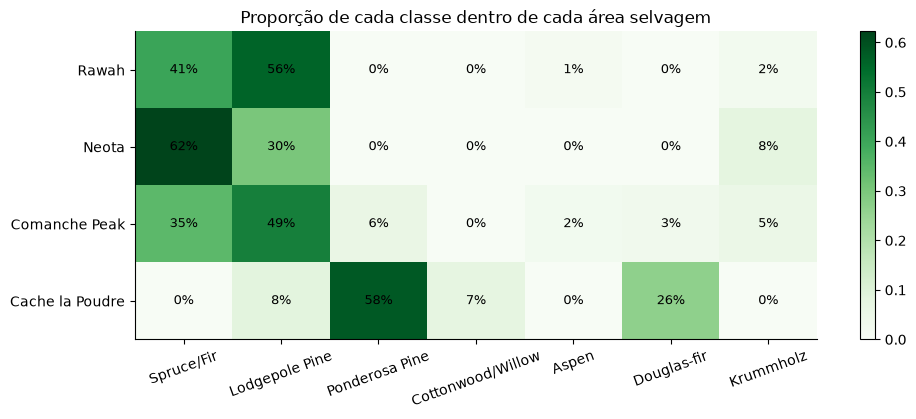

In [12]:
# Versão "desfeita" do one-hot, usada só para análise exploratória
eda = pd.DataFrame({
    'Wilderness': pd.Categorical(df[COLS_WILD].to_numpy().argmax(axis=1)).rename_categories(
        ['Rawah', 'Neota', 'Comanche Peak', 'Cache la Poudre']),
    'Classe': df[ALVO].map(NOMES_CLASSES),
})
tabela_cruzada = pd.crosstab(eda['Wilderness'], eda['Classe'], normalize='index')[ROTULOS]

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(tabela_cruzada, cmap='Greens', aspect='auto')
ax.set_xticks(range(len(ROTULOS)), ROTULOS, rotation=20)
ax.set_yticks(range(len(tabela_cruzada)), tabela_cruzada.index)
for i in range(tabela_cruzada.shape[0]):
    for j in range(tabela_cruzada.shape[1]):
        ax.text(j, i, f'{tabela_cruzada.iat[i, j]:.0%}', ha='center', va='center', fontsize=9)
ax.set_title('Proporção de cada classe dentro de cada área selvagem')
plt.colorbar(im)
plt.show()

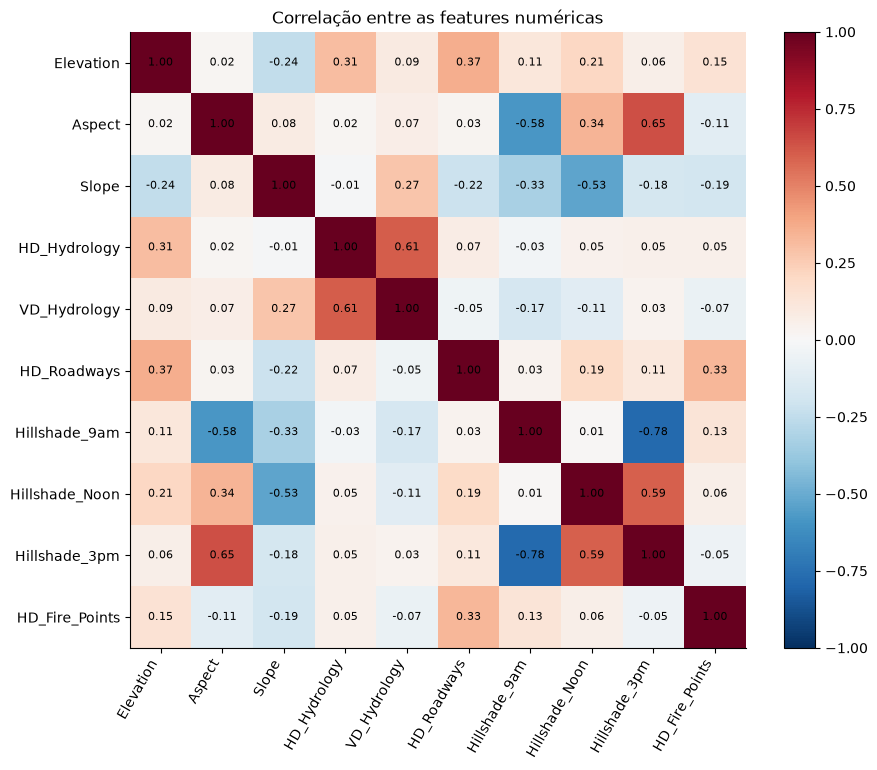

In [13]:
correlacao = df[COLS_NUM].corr()
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(correlacao, cmap='RdBu_r', vmin=-1, vmax=1)
nomes_curtos = [c.replace('Horizontal_Distance_To_', 'HD_').replace('Vertical_Distance_To_', 'VD_') for c in COLS_NUM]
ax.set_xticks(range(len(COLS_NUM)), nomes_curtos, rotation=60, ha='right')
ax.set_yticks(range(len(COLS_NUM)), nomes_curtos)
for i in range(len(COLS_NUM)):
    for j in range(len(COLS_NUM)):
        ax.text(j, i, f'{correlacao.iat[i, j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Correlação entre as features numéricas')
plt.colorbar(im)
plt.show()

Observações da análise exploratória:
- A **área selvagem** carrega muita informação. Cottonwood/Willow, por exemplo, só aparece em Cache la Poudre.
- Os três `Hillshade` são correlacionados com `Aspect` e `Slope` (são derivados da geometria do terreno), e `Hillshade_9am` × `Hillshade_3pm` têm correlação negativa forte. Há **redundância** entre features, outro argumento para testar redução de dimensionalidade.

#### 2.7) Divisão treino / validação / teste

- **Treino (60%)**: ajuste dos modelos.
- **Validação (20%)**: comparação entre versões (baseline, V1, tunning) e escolha de hiperparâmetros.
- **Teste (20%)**: guardado até a seção 4 e usado **uma única vez**, para a estimativa final e imparcial.

As três divisões são estratificadas pelo alvo.

In [14]:
X = df.drop(columns=ALVO)
y = df[ALVO]

X_temp, X_teste, y_temp, y_teste = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_treino, X_val, y_treino, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE)
del X_temp, y_temp

print(f'Treino:    {len(X_treino):>7,} linhas')
print(f'Validação: {len(X_val):>7,} linhas')
print(f'Teste:     {len(X_teste):>7,} linhas')

proporcoes = pd.DataFrame({nome: s.value_counts(normalize=True).sort_index() * 100
                           for nome, s in [('treino %', y_treino), ('validação %', y_val), ('teste %', y_teste)]})
proporcoes.index = proporcoes.index.map(NOMES_CLASSES)
display(proporcoes.round(2))

# Para os GridSearch: treino + validação, com a validação como "fold" fixo de avaliação
X_tv = pd.concat([X_treino, X_val])
y_tv = pd.concat([y_treino, y_val])
divisao_val = PredefinedSplit(np.r_[np.full(len(X_treino), -1), np.zeros(len(X_val))])

Treino:    348,606 linhas
Validação: 116,203 linhas
Teste:     116,203 linhas


,treino %,validação %,teste %
Cover_Type,,,
Spruce/Fir,36.46,36.46,36.46
Lodgepole Pine,48.76,48.76,48.76
Ponderosa Pine,6.15,6.15,6.15
Cottonwood/Willow,0.47,0.47,0.47
Aspen,1.63,1.63,1.63
Douglas-fir,2.99,2.99,2.99
Krummholz,3.53,3.53,3.53


#### 2.8) Funções de avaliação (iguais para os dois métodos)

Para que as comparações sejam consistentes, todas as versões são avaliadas pela mesma função e com as mesmas métricas:
- **Acurácia**: fração de acertos (fácil de interpretar, mas inflada pela classe majoritária).
- **F1-macro** (**métrica principal**): média simples do F1 de cada classe, de modo que as classes raras pesam tanto quanto as grandes.
- **Balanced accuracy**: média do *recall* de cada classe.
- **Gap treino × validação**: diferença entre o F1-macro no treino e na validação. Um gap grande indica **overfitting**; F1 baixo nos dois conjuntos com gap pequeno indica **underfitting**.

Para diagnosticar overfitting e underfitting, além do gap, uso **curvas de validação** (no tunning) e, no modelo final de cada método, **validação cruzada estratificada de 5 folds** e **curva de aprendizado** (função `diagnosticar`).

In [15]:
resultados = []         # métricas de treino e validação de cada versão
predicoes_teste = {}    # predições no teste, analisadas só na seção 4


def avaliar(metodo, versao, modelo, preparar=None):
    """Treina no treino, mede treino e validação e guarda as predições do teste para a seção 4."""
    preparar = preparar or (lambda dados: dados)
    X_tr, X_va, X_te = preparar(X_treino), preparar(X_val), preparar(X_teste)

    inicio = time.time()
    with warnings.catch_warnings(record=True) as avisos:
        warnings.simplefilter('always', ConvergenceWarning)
        modelo.fit(X_tr, y_treino)
    tempo = time.time() - inicio
    convergiu = not any(issubclass(a.category, ConvergenceWarning) for a in avisos)

    p_tr, p_va = modelo.predict(X_tr), modelo.predict(X_va)
    predicoes_teste[(metodo, versao)] = modelo.predict(X_te)
    # nº de features que chegam ao classificador (depois de PCA, polinômios etc.)
    n_features = modelo[:-1].transform(X_tr.head()).shape[1] if isinstance(modelo, Pipeline) else X_tr.shape[1]

    linha = {'método': metodo, 'versão': versao,
             'acurácia treino': accuracy_score(y_treino, p_tr),
             'acurácia val': accuracy_score(y_val, p_va),
             'F1-macro treino': f1_score(y_treino, p_tr, average='macro'),
             'F1-macro val': f1_score(y_val, p_va, average='macro'),
             'bal. acc. val': balanced_accuracy_score(y_val, p_va),
             'nº features': n_features,
             'tempo treino (s)': round(tempo, 1)}
    linha['gap F1 (treino - val)'] = linha['F1-macro treino'] - linha['F1-macro val']
    resultados[:] = [r for r in resultados if (r['método'], r['versão']) != (metodo, versao)]  # evita duplicar ao re-executar
    resultados.append(linha)

    if not convergiu:
        print('ATENÇÃO: o otimizador NÃO convergiu (ConvergenceWarning).')
    display(pd.DataFrame([linha]).set_index(['método', 'versão']).round(4))
    return modelo, p_va

In [16]:
def comparar(metodo):
    """Tabela e gráfico com todas as versões de um método, medidas na validação."""
    tabela = pd.DataFrame([r for r in resultados if r['método'] == metodo]).set_index('versão').drop(columns='método')
    display(tabela.round(4))
    ax = tabela[['F1-macro treino', 'F1-macro val', 'acurácia val', 'bal. acc. val']].plot.bar(
        figsize=(12, 5), rot=10, ylim=(0, 1.05), color=['lightgray', 'seagreen', 'steelblue', 'darkorange'])
    for container in ax.containers[1:2]:
        ax.bar_label(container, fmt='%.3f', fontsize=8)
    ax.set_title(f'{metodo}: comparação entre versões (validação)')
    ax.legend(loc='lower right')
    plt.show()


def relatorio(y_real, y_pred, titulo):
    """Relatório por classe + matriz de confusão normalizada pela linha (recall de cada classe)."""
    print(classification_report(y_real, y_pred, target_names=ROTULOS, digits=3, zero_division=0))
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(y_real, y_pred, normalize='true', display_labels=ROTULOS,
                                            values_format='.2f', cmap='Greens', colorbar=False,
                                            xticks_rotation=45, ax=ax)
    ax.set_title(titulo)
    plt.show()


def escalonador():
    """Padroniza só as 10 numéricas; as 44 binárias (0/1) passam direto."""
    return ColumnTransformer([('num', StandardScaler(), COLS_NUM)], remainder='passthrough')


def diagnosticar(metodo, modelo, preparar=None, n_jobs=None):
    """Validação cruzada estratificada (5 folds) + curva de aprendizado, em treino + validação (teste fica de fora)."""
    preparar = preparar or (lambda dados: dados)
    X_diag = preparar(X_tv)
    inicio = time.time()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore', ConvergenceWarning)
        cv = cross_validate(modelo, X_diag, y_tv, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                            scoring=['f1_macro', 'accuracy'], return_train_score=True, n_jobs=n_jobs)
        tamanhos, f1_treino, f1_val = learning_curve(modelo, X_diag, y_tv, cv=divisao_val, scoring='f1_macro',
                                                     train_sizes=[0.02, 0.05, 0.1, 0.25, 0.5, 1.0],
                                                     shuffle=True, random_state=RANDOM_STATE, n_jobs=n_jobs)
    print(f'Diagnóstico concluído em {time.time() - inicio:.0f}s')

    folds = pd.DataFrame({'F1-macro treino': cv['train_f1_macro'], 'F1-macro val': cv['test_f1_macro'],
                          'acurácia treino': cv['train_accuracy'], 'acurácia val': cv['test_accuracy']},
                         index=[f'fold {i}' for i in range(1, 6)])
    folds['gap F1 (treino - val)'] = folds['F1-macro treino'] - folds['F1-macro val']
    display(pd.concat([folds, folds.agg(['mean', 'std']).rename(index={'mean': 'média', 'std': 'desvio'})]).round(4))
    print(f"Validação cruzada: F1-macro = {folds['F1-macro val'].mean():.4f} ± {folds['F1-macro val'].std():.4f} | "
          f"acurácia = {folds['acurácia val'].mean():.4f} ± {folds['acurácia val'].std():.4f}")

    curva = pd.DataFrame({'amostras de treino': tamanhos, 'F1-macro treino': f1_treino.mean(axis=1),
                          'F1-macro val': f1_val.mean(axis=1)})
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    posicoes = np.arange(1, 6)
    ax1.plot(posicoes, folds['F1-macro treino'], 'o--', label='treino')
    ax1.plot(posicoes, folds['F1-macro val'], 'o-', label='validação')
    ax1.set_xticks(posicoes, folds.index)
    ax1.set_ylim(folds[['F1-macro treino', 'F1-macro val']].min().min() - 0.05, 1.01)
    ax1.set_ylabel('F1-macro')
    ax1.set_title(f'{metodo}: validação cruzada (5 folds)')
    ax1.legend()
    ax2.plot(curva['amostras de treino'], curva['F1-macro treino'], 'o--', label='treino')
    ax2.plot(curva['amostras de treino'], curva['F1-macro val'], 'o-', label='validação')
    ax2.fill_between(curva['amostras de treino'], curva['F1-macro val'], curva['F1-macro treino'], alpha=0.15,
                     color='red', label='gap')
    ax2.set_xscale('log')
    ax2.set_xlabel('nº de amostras de treino (escala log)')
    ax2.set_ylabel('F1-macro')
    ax2.set_title(f'{metodo}: curva de aprendizado')
    ax2.legend()
    plt.tight_layout()
    plt.show()
    display(curva.round(4))

### 3) **(80%)** Nos blocos seguintes implemente seus classificadores (serão implementados 2 métodos diferentes).

#### 3.1) Qual método escolhido?

**Regressão Logística (multinomial / softmax).**

Para cada classe, o modelo aprende uma combinação linear das features, e a função softmax transforma os 7 escores em probabilidades. É um modelo **linear**: as fronteiras de decisão são hiperplanos.

Por que escolhi esse método:
- É rápido, interpretável (cada coeficiente mostra o peso de uma feature para uma classe) e serve como referência de modelo simples.
- É **sensível à escala** das features, o que torna a normalização uma melhoria natural para a Versão 1.
- Faz contraponto ao segundo método, o Random Forest, que é não-linear.

#### 3.2) **(10%)** Baseline - Implemente seu classificador da forma mais simples possível para esse ser seu baseline

Baseline: `LogisticRegression()` com todos os parâmetros padrão, treinada nos dados **sem nenhum tratamento** (sem normalização).

ATENÇÃO: o otimizador NÃO convergiu (ConvergenceWarning).


,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Regressão Logística,Baseline,0.6224,0.621,0.2358,0.2354,0.233,54,10.5,0.0004


                   precision    recall  f1-score   support

       Spruce/Fir      0.619     0.633     0.626     42368
   Lodgepole Pine      0.625     0.772     0.691     56660
   Ponderosa Pine      0.604     0.222     0.325      7151
Cottonwood/Willow      0.000     0.000     0.000       549
            Aspen      0.000     0.000     0.000      1899
      Douglas-fir      0.108     0.003     0.006      3474
        Krummholz      0.000     0.000     0.000      4102

         accuracy                          0.621    116203
        macro avg      0.279     0.233     0.235    116203
     weighted avg      0.570     0.621     0.585    116203



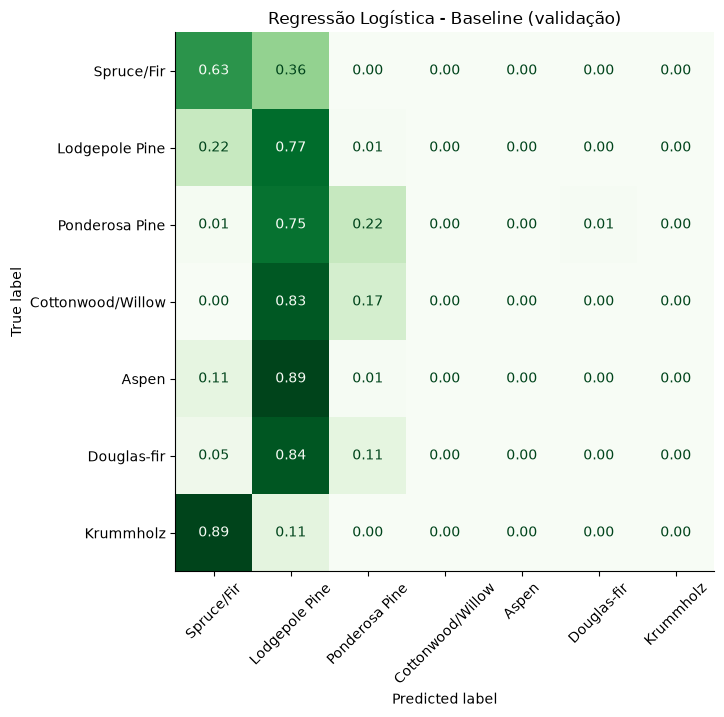

In [17]:
lr_base, p_val = avaliar('Regressão Logística', 'Baseline', LogisticRegression(random_state=RANDOM_STATE))
relatorio(y_val, p_val, 'Regressão Logística - Baseline (validação)')

**Análise do baseline:**
- O otimizador **não convergiu** em 100 iterações. Com features em escalas muito diferentes (`Slope` vai até 66; as distâncias, até 7.173), o problema de otimização fica mal condicionado.
- A acurácia de 62% parece razoável, mas o **F1-macro é de apenas 0,235**. O modelo praticamente só prevê as duas classes majoritárias: Cottonwood/Willow, Aspen, Douglas-fir e Krummholz têm *recall* perto de zero, como mostra a matriz de confusão. É exatamente o caso em que a acurácia engana.
- O F1 no treino é praticamente igual ao da validação (gap ≈ 0), e os dois são baixos. Isso é **underfitting** (alto viés), não overfitting.

#### 3.3) **(20%)** Versão 1 - O que podemos fazer para melhorar nosso baseline? Aplique técnicas como redução de dimensionalidade, normalização ou outras. Compare os resultados.

Três melhorias, testadas uma a uma e todas comparadas na validação:

- **V1a. Normalização:** `StandardScaler` nas 10 numéricas. As escalas vão de 0–66 (`Slope`) a 0–7.173 (distâncias), o que atrapalha o gradiente do otimizador. `max_iter` sobe para 1000 para garantir a convergência.
- **V1b. Redução de dimensionalidade com PCA:** depois da normalização, mantém os componentes que explicam 95% da variância.
- **V1c. Features polinomiais de grau 2** nas 10 numéricas (quadrados e interações). Dão ao modelo linear alguma capacidade de criar fronteiras curvas.

Todos os pré-processamentos ficam dentro de um `Pipeline`, de modo que o scaler e o PCA são ajustados **só no treino**, sem vazamento de dados.

In [18]:
lr_v1a, p_val = avaliar('Regressão Logística', 'V1a: padronização',
                        Pipeline([('prep', escalonador()),
                                  ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]))

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Regressão Logística,V1a: padronização,0.725,0.7237,0.5333,0.5325,0.5121,54,20.0,0.0008


**V1b. PCA:** primeiro, quanta variância cada componente explica?

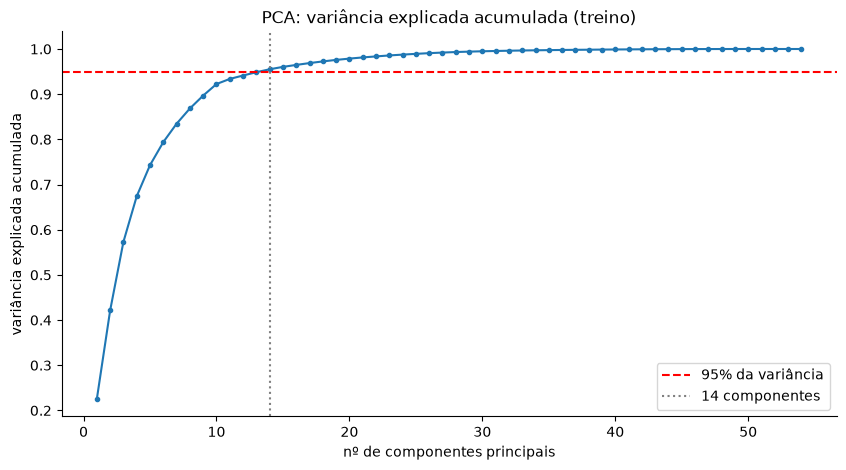

14 componentes explicam 95% da variância (de 54 features originais).


In [19]:
pca_analise = Pipeline([('prep', escalonador()), ('pca', PCA(random_state=RANDOM_STATE))]).fit(X_treino)
var_acumulada = np.cumsum(pca_analise.named_steps['pca'].explained_variance_ratio_)
n_95 = int(np.argmax(var_acumulada >= 0.95) + 1)

fig, ax = plt.subplots()
ax.plot(range(1, len(var_acumulada) + 1), var_acumulada, marker='o', markersize=3)
ax.axhline(0.95, color='red', linestyle='--', label='95% da variância')
ax.axvline(n_95, color='gray', linestyle=':', label=f'{n_95} componentes')
ax.set_xlabel('nº de componentes principais')
ax.set_ylabel('variância explicada acumulada')
ax.set_title('PCA: variância explicada acumulada (treino)')
ax.legend()
plt.show()
print(f'{n_95} componentes explicam 95% da variância (de 54 features originais).')

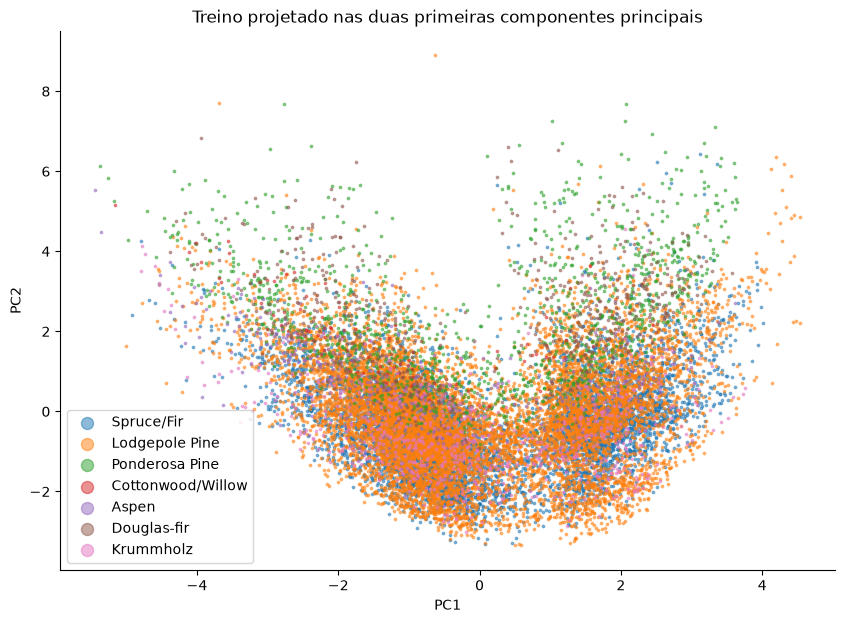

In [20]:
# Visualização das duas primeiras componentes (amostra de 20 mil pontos do treino)
amostra = X_treino.sample(20_000, random_state=RANDOM_STATE)
pcs = pca_analise.transform(amostra)
fig, ax = plt.subplots(figsize=(10, 7))
for k, nome in NOMES_CLASSES.items():
    mascara = (y_treino.loc[amostra.index] == k).to_numpy()
    ax.scatter(pcs[mascara, 0], pcs[mascara, 1], s=3, alpha=0.5, label=nome)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Treino projetado nas duas primeiras componentes principais')
ax.legend(markerscale=5)
plt.show()

In [21]:
lr_v1b, p_val = avaliar('Regressão Logística', f'V1b: padronização + PCA ({n_95} comp.)',
                        Pipeline([('prep', escalonador()),
                                  ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
                                  ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]))

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Regressão Logística,V1b: padronização + PCA (14 comp.),0.7085,0.7077,0.4699,0.4707,0.4453,14,10.9,-0.0008


In [22]:
def polinomial():
    """Padroniza as numéricas, cria termos de grau 2 e padroniza de novo; binárias passam direto."""
    numericas = Pipeline([('esc', StandardScaler()),
                          ('poli', PolynomialFeatures(degree=2, include_bias=False)),
                          ('esc2', StandardScaler())])
    return ColumnTransformer([('num', numericas, COLS_NUM)], remainder='passthrough')


lr_v1c, p_val = avaliar('Regressão Logística', 'V1c: padronização + polinomial',
                        Pipeline([('prep', polinomial()),
                                  ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]))

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Regressão Logística,V1c: padronização + polinomial,0.7429,0.7406,0.6298,0.6297,0.5974,109,80.1,0.0001


,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
versão,,,,,,,,
Baseline,0.6224,0.6210,0.2358,0.2354,0.2330,54,10.5,0.0004
V1a: padronização,0.7250,0.7237,0.5333,0.5325,0.5121,54,20.0,0.0008
V1b: padronização + PCA (14 comp.),0.7085,0.7077,0.4699,0.4707,0.4453,14,10.9,-0.0008
V1c: padronização + polinomial,0.7429,0.7406,0.6298,0.6297,0.5974,109,80.1,0.0001


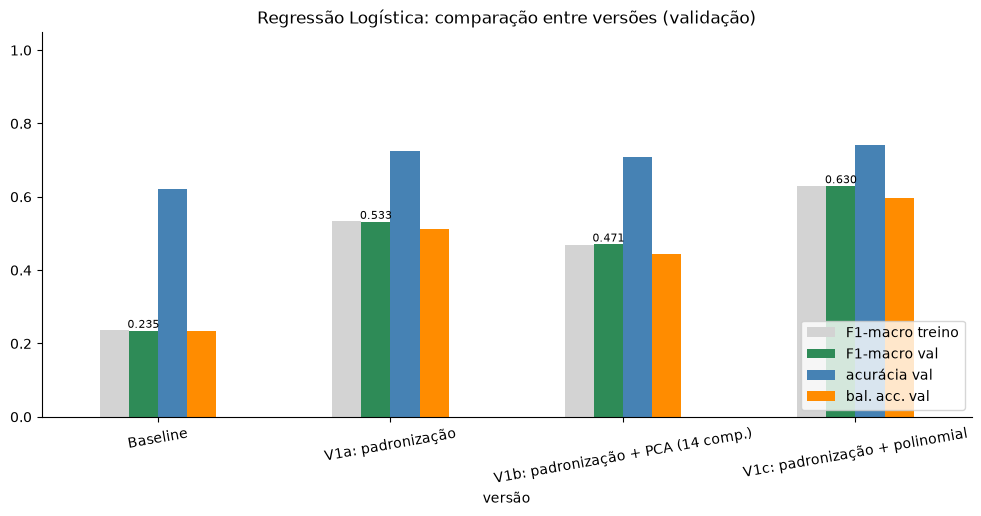

In [23]:
comparar('Regressão Logística')

**Análise da Versão 1:**
- **V1a (padronização)** foi a mudança mais importante. O modelo passa a convergir, o F1-macro sobe de **0,235 para 0,533** e a acurácia de 62,1% para 72,4%. Isso confirma que o problema do baseline era a escala, e não o modelo em si.
- **V1b (PCA)** **piorou** o resultado (F1-macro 0,471). Há três razões:
  1. O PCA é não supervisionado: ele preserva a variância, não a informação que separa as classes.
  2. As colunas binárias de solo, raras, têm variância pequena e são as primeiras a ser descartadas, mas são justamente elas que ajudam a separar as classes raras.
  3. Para um modelo linear, combinações lineares das features não acrescentam capacidade, só podem remover informação.

  Com 348 mil amostras, 54 features não são "muitas", então a redução não compensa.
- **V1c (features polinomiais)** foi a melhor versão: F1-macro **0,630** e acurácia 74,1%. Os quadrados e interações permitem fronteiras curvas. O custo é um tempo de treino cerca de 4x maior (109 features em vez de 54).
- Em todas as versões, o gap treino × validação continua ≈ 0. O modelo segue em **underfitting**: o limite é a capacidade de um modelo linear, não a falta de regularização.

#### 3.4) **(10%)** Tunning - Agora que temos um resultado promissor, vamos tentar melhorar o resultado alterando um ou mais hiper-parametro. Compare os resultados.

Partindo da melhor versão (V1c), vou variar dois hiper-parâmetros:
- **`C`**: inverso da força da regularização L2. `C` pequeno significa mais regularização (risco de underfitting); `C` grande significa menos regularização (risco de overfitting).
- **`class_weight`**: `None` ou `'balanced'`, que dá mais peso às classes raras no treino.

A busca usa `GridSearchCV` com a **validação como fold fixo** (`PredefinedSplit`), otimizando o F1-macro e registrando também o score de treino, para enxergar under e overfitting.

In [24]:
busca_lr = GridSearchCV(
    Pipeline([('prep', polinomial()), ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    param_grid={'lr__C': [0.001, 0.01, 0.1, 1, 10, 100],
                'lr__class_weight': [None, 'balanced']},
    scoring='f1_macro', cv=divisao_val, return_train_score=True, refit=False, n_jobs=6)

inicio = time.time()
with warnings.catch_warnings():
    warnings.simplefilter('ignore', ConvergenceWarning)
    busca_lr.fit(X_tv, y_tv)
print(f'Busca concluída em {time.time() - inicio:.0f}s')

cv_lr = pd.DataFrame(busca_lr.cv_results_)
cv_lr['class_weight'] = cv_lr['param_lr__class_weight'].astype(str)
display(cv_lr[['param_lr__C', 'class_weight', 'mean_train_score', 'mean_test_score']]
        .rename(columns={'param_lr__C': 'C', 'mean_train_score': 'F1-macro treino', 'mean_test_score': 'F1-macro val'})
        .sort_values('F1-macro val', ascending=False).round(4))
print('Melhores hiper-parâmetros:', busca_lr.best_params_)

Busca concluída em 577s


,C,class_weight,F1-macro treino,F1-macro val
10,100.000,NaN,0.6399,0.6394
8,10.000,NaN,0.6344,0.6320
6,1.000,NaN,0.6292,0.6286
4,0.100,NaN,0.6147,0.6131
2,0.010,NaN,0.5852,0.5873
9,10.000,balanced,0.5577,0.5531
11,100.000,balanced,0.5575,0.5527
7,1.000,balanced,0.5561,0.5514
5,0.100,balanced,0.5485,0.5444
3,0.010,balanced,0.5372,0.5330


Melhores hiper-parâmetros: {'lr__C': 100, 'lr__class_weight': None}


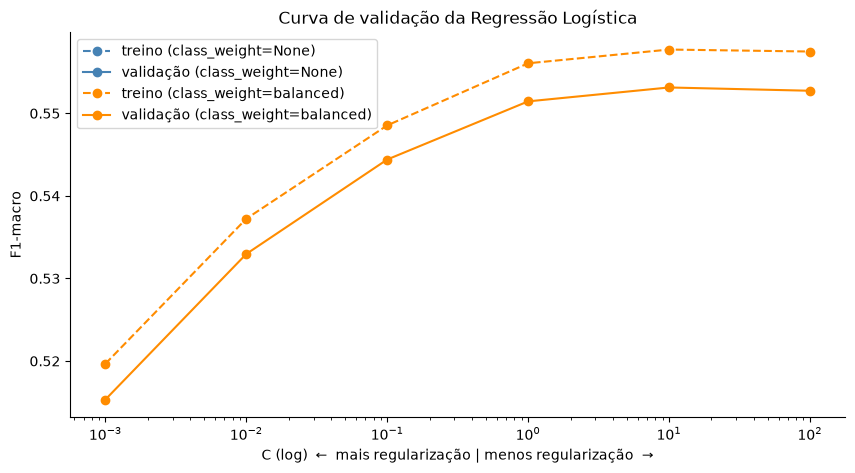

In [25]:
fig, ax = plt.subplots()
for cw, cor in [('None', 'steelblue'), ('balanced', 'darkorange')]:
    parte = cv_lr[cv_lr['class_weight'] == cw].sort_values('param_lr__C')
    ax.plot(parte['param_lr__C'], parte['mean_train_score'], '--', color=cor, marker='o', label=f'treino (class_weight={cw})')
    ax.plot(parte['param_lr__C'], parte['mean_test_score'], '-', color=cor, marker='o', label=f'validação (class_weight={cw})')
ax.set_xscale('log')
ax.set_xlabel('C (log)  ←  mais regularização | menos regularização  →')
ax.set_ylabel('F1-macro')
ax.set_title('Curva de validação da Regressão Logística')
ax.legend()
plt.show()

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Regressão Logística,Tunado,0.7433,0.7409,0.64,0.6387,0.6102,109,110.2,0.0013


,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
versão,,,,,,,,
Baseline,0.6224,0.6210,0.2358,0.2354,0.2330,54,10.5,0.0004
V1a: padronização,0.7250,0.7237,0.5333,0.5325,0.5121,54,20.0,0.0008
V1b: padronização + PCA (14 comp.),0.7085,0.7077,0.4699,0.4707,0.4453,14,10.9,-0.0008
V1c: padronização + polinomial,0.7429,0.7406,0.6298,0.6297,0.5974,109,80.1,0.0001
Tunado,0.7433,0.7409,0.6400,0.6387,0.6102,109,110.2,0.0013


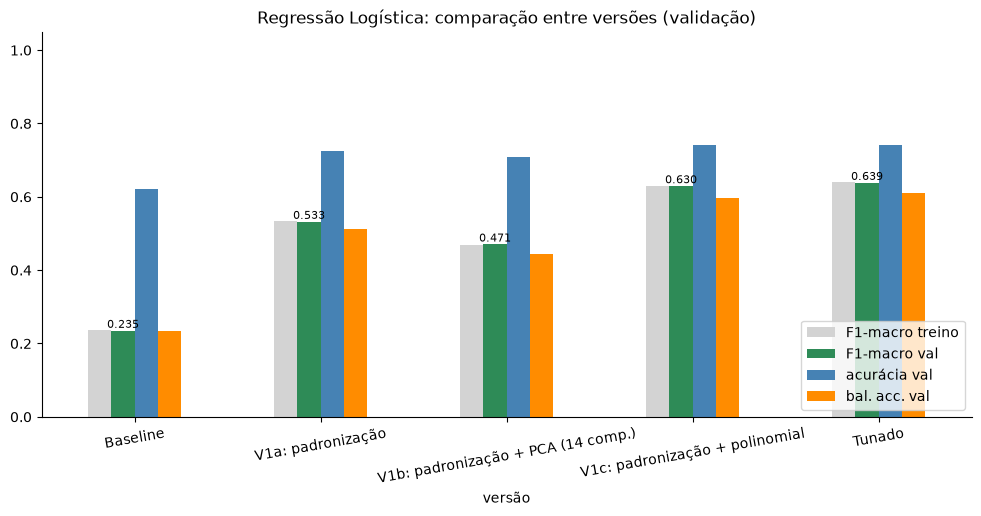

                   precision    recall  f1-score   support

       Spruce/Fir      0.729     0.704     0.716     42368
   Lodgepole Pine      0.756     0.804     0.779     56660
   Ponderosa Pine      0.728     0.810     0.767      7151
Cottonwood/Willow      0.782     0.698     0.737       549
            Aspen      0.611     0.178     0.276      1899
      Douglas-fir      0.527     0.380     0.441      3474
        Krummholz      0.821     0.698     0.755      4102

         accuracy                          0.741    116203
        macro avg      0.708     0.610     0.639    116203
     weighted avg      0.738     0.741     0.736    116203



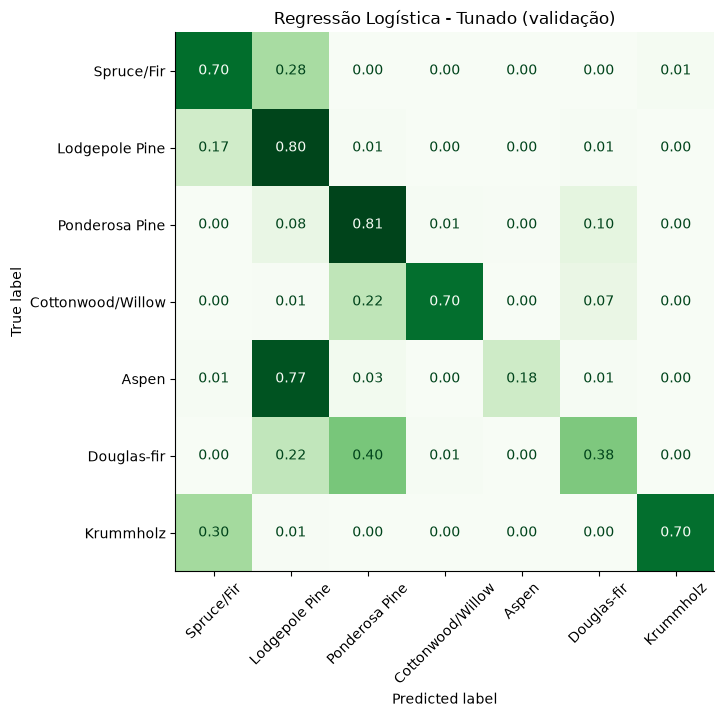

In [26]:
melhor_lr = busca_lr.best_params_
lr_tunado, p_val = avaliar('Regressão Logística', 'Tunado',
                           Pipeline([('prep', polinomial()),
                                     ('lr', LogisticRegression(C=melhor_lr['lr__C'],
                                                               class_weight=melhor_lr['lr__class_weight'],
                                                               max_iter=1000, random_state=RANDOM_STATE))]))
comparar('Regressão Logística')
relatorio(y_val, p_val, 'Regressão Logística - Tunado (validação)')

**Análise do tunning:**
- **Curva de validação:** o F1-macro cresce com `C`, e as curvas de treino e validação andam juntas em toda a faixa (gap sempre abaixo de 0,01). Mesmo com pouca regularização não há overfitting. Já com `C = 0,001` aparece um underfitting claro (F1 ≈ 0,51).
- **Melhor combinação:** `C = 100` e `class_weight = None`. O `C` ficou no limite da grade, mas o ganho de `C = 10` para `C = 100` já é pequeno (0,632 → 0,639), sinal de saturação.
- **`class_weight='balanced'`** piorou o F1-macro para todo `C ≥ 0,01` (≈ 0,55). Dar mais peso às classes raras não adianta quando o modelo linear não tem capacidade para separá-las: o ganho de *recall* nelas não compensa a perda de precisão no resto.
- **Resultado:** F1-macro de validação **0,639**, contra 0,630 da V1c. O ganho é pequeno porque o teto é o próprio modelo linear. Aspen (F1 0,28) continua sendo confundida com Lodgepole Pine, e Douglas-fir (F1 0,44) com Ponderosa Pine.

**Diagnóstico de overfitting e underfitting do modelo final**

Duas técnicas complementares, aplicadas no conjunto treino + validação (o teste continua intocado):
- **Validação cruzada estratificada (5 folds):** o modelo é treinado e avaliado 5 vezes, cada vez com uma parte diferente dos dados como validação. A média ± desvio mostra se o resultado é **estável** ou se dependeu da divisão escolhida, e o gap treino × validação aparece em cada fold.
- **Curva de aprendizado:** F1-macro no treino e na validação conforme aumenta a quantidade de dados de treino. Curvas **juntas e baixas** indicam **underfitting** (mais dados não ajudam). Curvas **separadas**, com a validação subindo, indicam **variância/overfitting** (mais dados ajudam).

Diagnóstico concluído em 527s


,F1-macro treino,F1-macro val,acurácia treino,acurácia val,gap F1 (treino - val)
fold 1,0.6409,0.6375,0.7439,0.7403,0.0034
fold 2,0.6385,0.6364,0.7426,0.7439,0.0021
fold 3,0.6341,0.6329,0.7428,0.7433,0.0013
fold 4,0.6385,0.6351,0.7427,0.7435,0.0034
fold 5,0.6382,0.6375,0.7433,0.7418,0.0007
média,0.6380,0.6359,0.7431,0.7426,0.0022
desvio,0.0024,0.0019,0.0006,0.0015,0.0012


Validação cruzada: F1-macro = 0.6359 ± 0.0019 | acurácia = 0.7426 ± 0.0015


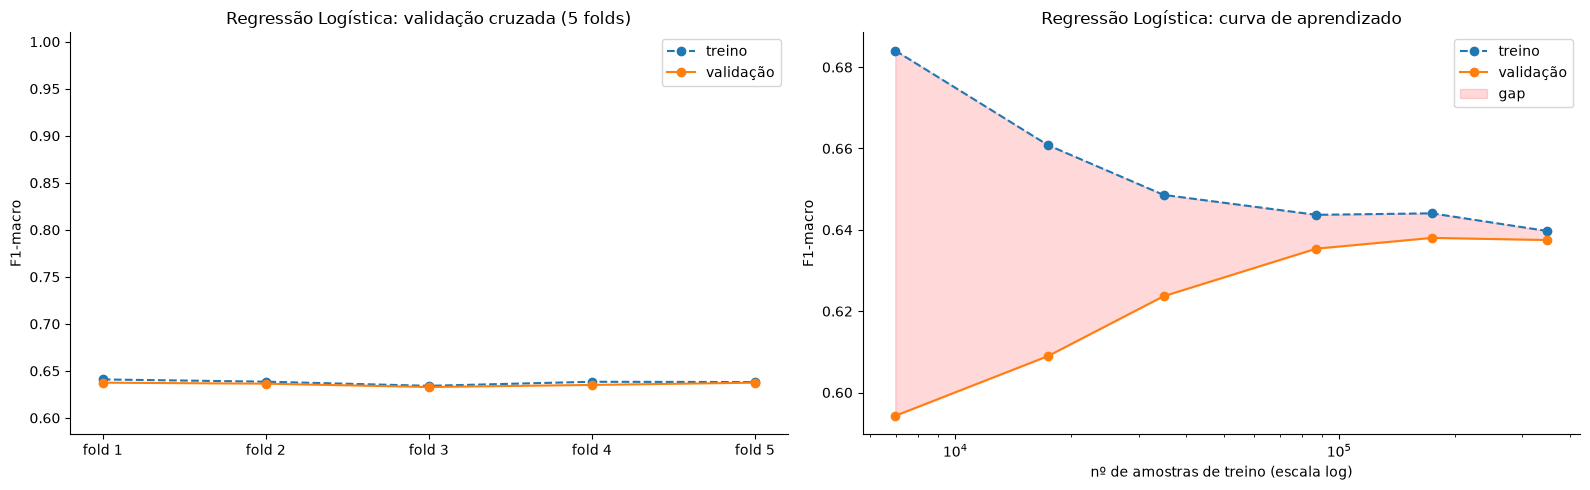

,amostras de treino,F1-macro treino,F1-macro val
0,6972,0.6841,0.5943
1,17430,0.6608,0.6090
2,34860,0.6486,0.6237
3,87151,0.6437,0.6354
4,174303,0.6441,0.6380
5,348606,0.6397,0.6375


In [27]:
diagnosticar('Regressão Logística',
             Pipeline([('prep', polinomial()),
                       ('lr', LogisticRegression(C=melhor_lr['lr__C'], class_weight=melhor_lr['lr__class_weight'],
                                                 max_iter=1000, random_state=RANDOM_STATE))]),
             n_jobs=5)

**Análise do diagnóstico:**
- **Validação cruzada:** F1-macro de **0,636 ± 0,002** e acurácia de **74,3% ± 0,2%** nos 5 folds. O desvio é muito pequeno, então o resultado é **estável** e não dependeu da divisão treino/validação escolhida.
- **Gap treino × validação:** a média é de 0,002, e nenhum fold passa de 0,004. **Não há overfitting.**
- **Curva de aprendizado:** com poucos dados (7 mil amostras) existe um gap (treino 0,684, validação 0,594). A partir de cerca de 87 mil amostras, as duas curvas se encontram em ~0,64 e ficam **planas** até as 349 mil. Esse é o retrato típico de **underfitting (alto viés)**: mais dados não melhoram o modelo. O limite é a capacidade do modelo linear, e só um modelo mais flexível supera esse teto, o que confirma a conclusão do tunning.

#### 3.5) Qual método escolhido?

**Random Forest.**

É um *ensemble* de árvores de decisão. Cada árvore é treinada em uma amostra *bootstrap* do treino e, a cada divisão, considera só um subconjunto aleatório de features. A previsão final é a votação das árvores.

Por que escolhi esse método:
- Árvores capturam relações **não-lineares** e interações entre features sem precisar de engenharia manual, ao contrário da Regressão Logística.
- **Não depende da escala** das features, o que permite comparar como cada método reage ao pré-processamento.
- A média de muitas árvores reduz a variância (o overfitting) de uma árvore individual.
- Fornece importância das features, o que ajuda a interpretar e a reduzir dimensionalidade.

#### 3.6) **(10%)** Baseline - Implemente seu classificador da forma mais simples possível para esse ser seu baseline

Baseline: `RandomForestClassifier()` com todos os parâmetros padrão, sobre as 54 features originais. `n_jobs=-1` só paraleliza o treino e não altera o modelo.

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Random Forest,Baseline,1.0,0.9475,1.0,0.9168,0.8984,54,16.0,0.0832


                   precision    recall  f1-score   support

       Spruce/Fir      0.958     0.934     0.946     42368
   Lodgepole Pine      0.942     0.968     0.955     56660
   Ponderosa Pine      0.933     0.956     0.944      7151
Cottonwood/Willow      0.919     0.852     0.885       549
            Aspen      0.922     0.751     0.828      1899
      Douglas-fir      0.920     0.888     0.904      3474
        Krummholz      0.973     0.940     0.956      4102

         accuracy                          0.947    116203
        macro avg      0.938     0.898     0.917    116203
     weighted avg      0.948     0.947     0.947    116203



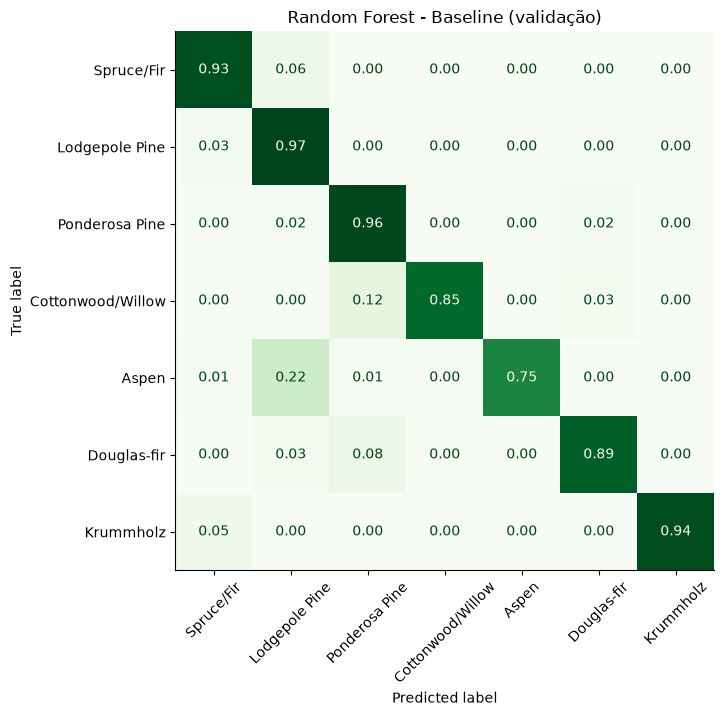

In [28]:
rf_base, p_val = avaliar('Random Forest', 'Baseline', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE))
relatorio(y_val, p_val, 'Random Forest - Baseline (validação)')

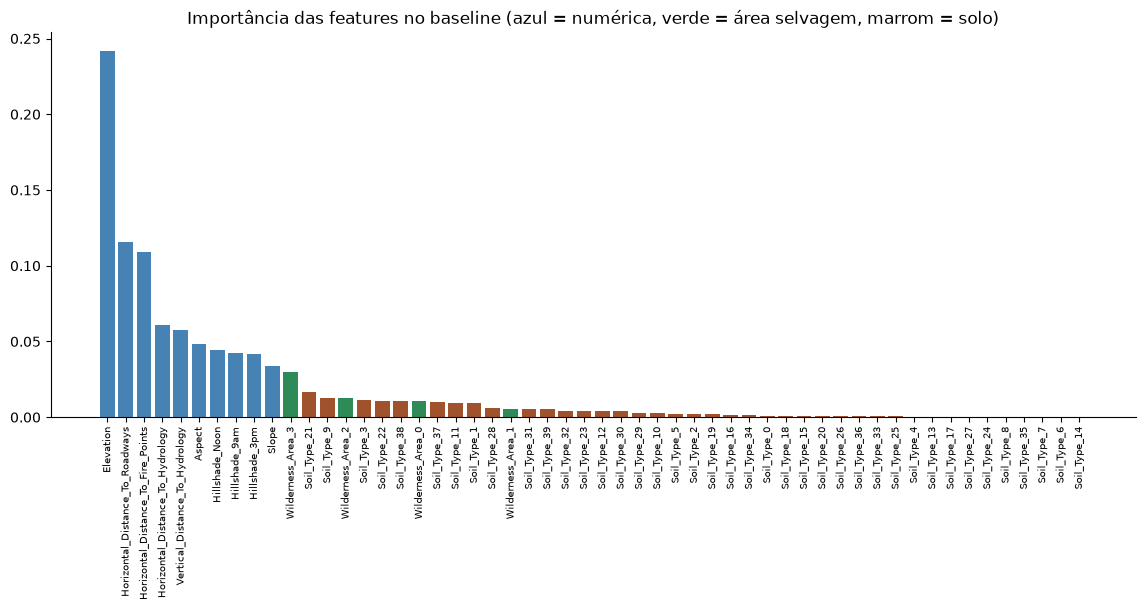

As 10 numéricas somam 80% da importância total.
As 40 colunas de solo somam 15%; 17 delas têm importância < 0,1%.


In [29]:
importancias = pd.Series(rf_base.feature_importances_, index=X_treino.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(14, 5))
cores = ['steelblue' if c in COLS_NUM else 'seagreen' if c in COLS_WILD else 'sienna' for c in importancias.index]
ax.bar(range(len(importancias)), importancias.values, color=cores)
ax.set_xticks(range(len(importancias)), importancias.index, rotation=90, fontsize=7)
ax.set_title('Importância das features no baseline (azul = numérica, verde = área selvagem, marrom = solo)')
plt.show()

print(f'As 10 numéricas somam {importancias[COLS_NUM].sum():.0%} da importância total.')
print(f'As 40 colunas de solo somam {importancias[COLS_SOIL].sum():.0%}; '
      f'{(importancias[COLS_SOIL] < 0.001).sum()} delas têm importância < 0,1%.')
del rf_base  # o modelo ocupa bastante memória; as predições já foram guardadas

**Análise do baseline:**
- Sem nenhum pré-processamento, o Random Forest já supera com folga a melhor Regressão Logística: acurácia **94,8%** e F1-macro **0,917** (contra 0,639).
- O F1 no treino é **1,000** e na validação é 0,917, um gap de **0,083**. Árvores totalmente crescidas memorizam o treino, o que é **overfitting** no nível de cada árvore. O *bagging* reduz o efeito (por isso a validação continua alta), mas há espaço para generalizar melhor.
- As classes mais difíceis são as mais raras: Aspen (*recall* 0,75) e Cottonwood/Willow (0,85).
- **Importâncias:** as 10 numéricas concentram 80% da importância. Das 40 colunas de solo, 17 têm importância abaixo de 0,1%. Isso motiva reduzir a dimensionalidade na Versão 1.

#### 3.7) **(20%)** Versão 1 - O que podemos fazer para melhorar nosso baseline? Aplique técnicas como redução de dimensionalidade, normalização ou outras. Compare os resultados.

Três melhorias, comparadas na validação:

- **V1a. Redução de dimensionalidade por compactação do one-hot:** as 4 colunas de área selvagem viram **1** coluna inteira (0–3), e as 40 de solo viram **1** coluna inteira (0–39). São **54 → 12 features**. Para uma árvore, um código inteiro funciona bem: ela isola qualquer valor com divisões sucessivas. Além disso, os códigos ELU de solo seguem uma ordem por zona climática. Com o one-hot, cada divisão só separa um tipo de solo de todos os outros, e as colunas raras quase nunca são sorteadas.
- **V1b. V1a + engenharia de features:** combinações das distâncias que representam a posição do terreno de outra forma (distância euclidiana até a água, altitude relativa à água, somas e diferenças entre distâncias). Árvores só cortam em eixos, então criar essas combinações ajuda.
- **V1c. Padronização + PCA (95%):** a redução de dimensionalidade clássica, para comparar. Uso **exatamente o mesmo pré-processamento da Regressão Logística** (padroniza só as 10 numéricas e mantém os componentes que explicam 95% da variância, ou seja, os mesmos 14 componentes), para que a comparação entre os dois métodos seja justa.

In [30]:
def compactar(X):
    """Desfaz o one-hot: 4 colunas de área selvagem -> 1 código; 40 colunas de solo -> 1 código."""
    Xc = X[COLS_NUM].copy()
    Xc['Wilderness'] = X[COLS_WILD].to_numpy().argmax(axis=1)
    Xc['Soil'] = X[COLS_SOIL].to_numpy().argmax(axis=1)
    return Xc


def engenharia(X):
    """Versão compacta + combinações de distâncias (operações linha a linha, sem vazamento)."""
    Xf = compactar(X)
    d = X[COLS_NUM].astype('float64')
    Xf['Dist_Hidro_Euclid'] = np.hypot(d['Horizontal_Distance_To_Hydrology'], d['Vertical_Distance_To_Hydrology'])
    Xf['Elevacao_Rel_Hidro'] = d['Elevation'] - d['Vertical_Distance_To_Hydrology']
    Xf['Hidro_mais_Fogo'] = d['Horizontal_Distance_To_Hydrology'] + d['Horizontal_Distance_To_Fire_Points']
    Xf['Hidro_menos_Fogo'] = d['Horizontal_Distance_To_Hydrology'] - d['Horizontal_Distance_To_Fire_Points']
    Xf['Hidro_mais_Estrada'] = d['Horizontal_Distance_To_Hydrology'] + d['Horizontal_Distance_To_Roadways']
    Xf['Fogo_menos_Estrada'] = d['Horizontal_Distance_To_Fire_Points'] - d['Horizontal_Distance_To_Roadways']
    return Xf


engenharia(X_treino.head())

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Wilderness,Soil,Dist_Hidro_Euclid,Elevacao_Rel_Hidro,Hidro_mais_Fogo,Hidro_menos_Fogo,Hidro_mais_Estrada,Fogo_menos_Estrada
386302,2894,28,18,418,99,3115,210,199,119,1008,2,9,429.563732,2795.0,1426.0,-590.0,3533.0,-2107.0
137614,2963,273,19,218,52,5686,166,241,213,1128,0,28,224.116041,2911.0,1346.0,-910.0,5904.0,-4558.0
1187,3212,258,21,277,73,4723,167,247,216,3329,0,28,286.457676,3139.0,3606.0,-3052.0,5000.0,-1394.0
116350,2793,40,12,256,55,1648,221,214,126,2592,0,28,261.841555,2738.0,2848.0,-2336.0,1904.0,944.0
394270,2847,85,31,210,122,2030,246,172,31,485,2,12,242.866218,2725.0,695.0,-275.0,2240.0,-1545.0


In [31]:
modelo, _ = avaliar('Random Forest', 'V1a: one-hot compactado (12 feat.)',
                    RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE), preparar=compactar)
del modelo

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Random Forest,V1a: one-hot compactado (12 feat.),1.0,0.9566,1.0,0.9284,0.9144,12,12.7,0.0716


,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Random Forest,V1b: compactado + engenharia,1.0,0.9706,1.0,0.9451,0.9364,18,17.3,0.0549


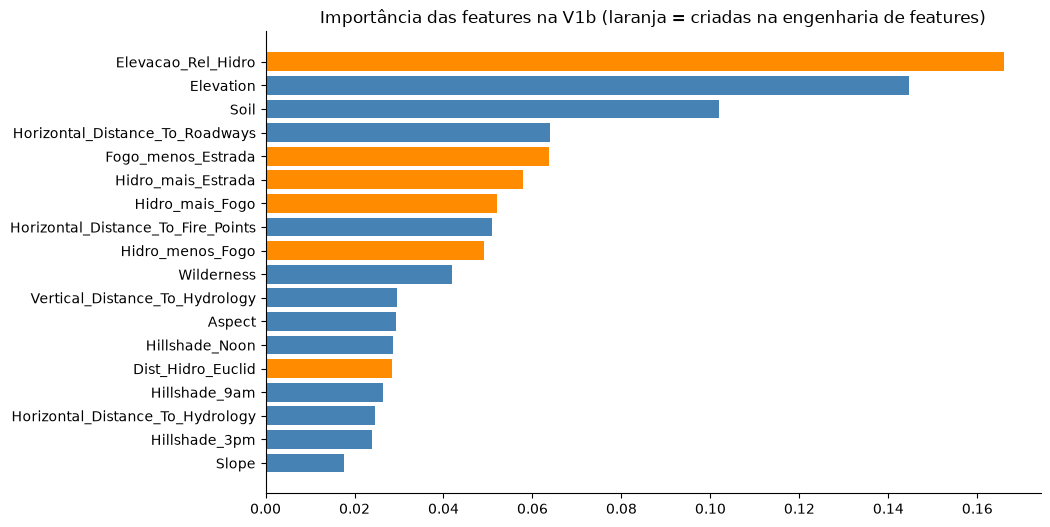

In [32]:
rf_v1b, p_val = avaliar('Random Forest', 'V1b: compactado + engenharia',
                        RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE), preparar=engenharia)
importancias_v1b = pd.Series(rf_v1b.feature_importances_, index=engenharia(X_treino.head()).columns).sort_values()
del rf_v1b

fig, ax = plt.subplots(figsize=(10, 6))
cores = ['darkorange' if c not in COLS_NUM + ['Wilderness', 'Soil'] else 'steelblue' for c in importancias_v1b.index]
ax.barh(importancias_v1b.index, importancias_v1b.values, color=cores)
ax.set_title('Importância das features na V1b (laranja = criadas na engenharia de features)')
plt.show()

In [33]:
modelo, _ = avaliar('Random Forest', f'V1c: padronização + PCA ({n_95} comp.)',
                    Pipeline([('prep', escalonador()),
                              ('pca', PCA(n_components=0.95, random_state=RANDOM_STATE)),
                              ('rf', RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE))]))
del modelo

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Random Forest,V1c: padronização + PCA (14 comp.),1.0,0.9278,1.0,0.8716,0.8424,14,20.4,0.1284


,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
versão,,,,,,,,
Baseline,1.0,0.9475,1.0,0.9168,0.8984,54,16.0,0.0832
V1a: one-hot compactado (12 feat.),1.0,0.9566,1.0,0.9284,0.9144,12,12.7,0.0716
V1b: compactado + engenharia,1.0,0.9706,1.0,0.9451,0.9364,18,17.3,0.0549
V1c: padronização + PCA (14 comp.),1.0,0.9278,1.0,0.8716,0.8424,14,20.4,0.1284


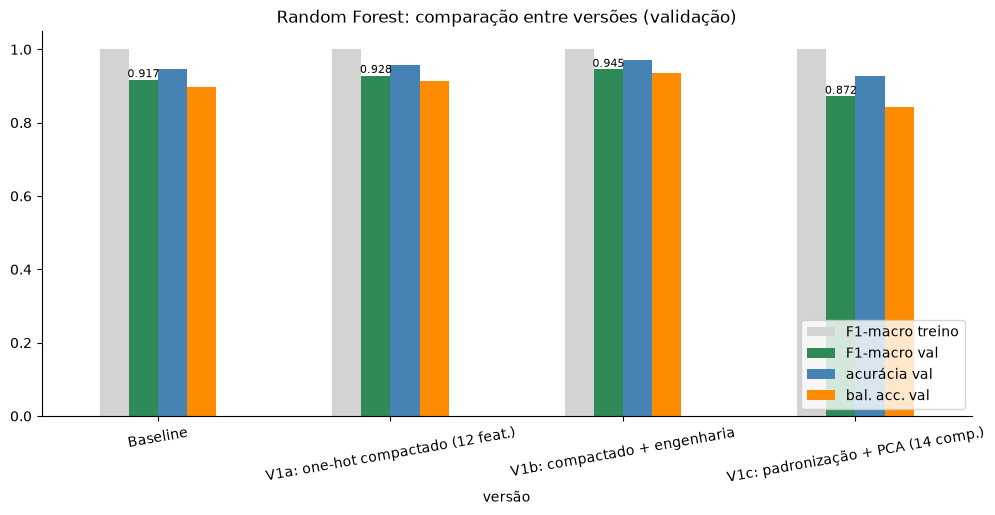

In [34]:
comparar('Random Forest')

**Análise da Versão 1:**
- **V1a (one-hot compactado):** as features caem de **54 para 12** e o modelo **melhora** (F1-macro de 0,917 para 0,928), além de treinar mais rápido. É uma redução de dimensionalidade **sem perda de informação**: a transformação é reversível. Ela só muda a forma como a árvore enxerga solo e área selvagem.
- **V1b (compactado + engenharia de features)** teve o maior ganho: F1-macro **0,945** e acurácia **97,1%**, com o gap treino × validação caindo de 0,083 para 0,055. A feature criada `Elevacao_Rel_Hidro` passou a ser a mais importante, à frente da própria `Elevation`.
- **V1c (PCA, 14 componentes)** foi a **pior versão**: F1-macro **0,872**, contra 0,917 do baseline, e o maior gap treino × validação (0,128). O PCA gera eixos rotacionados (combinações de várias features), e uma árvore só corta em eixos. Ela perde divisões simples e muito informativas, como "Elevation > 3.000 m". Além disso, o PCA não usa o alvo e, como na Regressão Logística, descarta boa parte da informação das colunas binárias de solo, que têm pouca variância.
- **Lição, que vale também para a Regressão Logística:** a redução de dimensionalidade funciona quando respeita a estrutura do dado (V1a) e atrapalha quando é aplicada às cegas (V1c).
- A **V1b** segue para o tunning.

#### 3.8) **(10%)** Tunning - Agora que temos um resultado promissor, vamos tentar melhorar o resultado alterando um ou mais hiper-parametro. Compare os resultados.

Partindo da V1b, vou variar três hiper-parâmetros. Todos são avaliados na validação, com registro do score de treino para diagnosticar under e overfitting:

1. **`max_depth`** (profundidade máxima): curva de validação para enxergar a transição de underfitting para overfitting.
2. **`max_features` × `min_samples_leaf`**: quantas features cada divisão sorteia e o tamanho mínimo de uma folha.
3. **`n_estimators`**: quantas árvores compensam.

Busca concluída em 142s


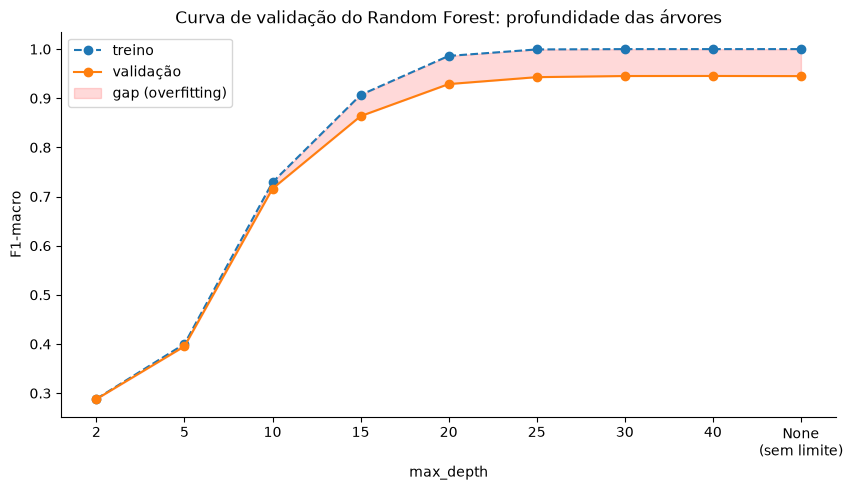

,max_depth,F1-macro treino,F1-macro val
0,2,0.2884,0.2880
1,5,0.4001,0.3953
2,10,0.7292,0.7162
3,15,0.9068,0.8636
4,20,0.9862,0.9289
5,25,0.9993,0.9429
6,30,1.0000,0.9452
7,40,1.0000,0.9454
8,None,1.0000,0.9451


In [35]:
profundidades = [2, 5, 10, 15, 20, 25, 30, 40, None]
busca_prof = GridSearchCV(RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
                          param_grid={'max_depth': profundidades},
                          scoring='f1_macro', cv=divisao_val, return_train_score=True, refit=False)
inicio = time.time()
busca_prof.fit(engenharia(X_tv), y_tv)
print(f'Busca concluída em {time.time() - inicio:.0f}s')

cv_prof = pd.DataFrame(busca_prof.cv_results_)
rotulos_prof = [str(p) if p is not None else 'None\n(sem limite)' for p in profundidades]
posicoes = range(len(profundidades))
fig, ax = plt.subplots()
ax.plot(posicoes, cv_prof['mean_train_score'], 'o--', label='treino')
ax.plot(posicoes, cv_prof['mean_test_score'], 'o-', label='validação')
ax.fill_between(posicoes, cv_prof['mean_test_score'], cv_prof['mean_train_score'], alpha=0.15, color='red',
                label='gap (overfitting)')
ax.set_xticks(posicoes, rotulos_prof)
ax.set_xlabel('max_depth')
ax.set_ylabel('F1-macro')
ax.set_title('Curva de validação do Random Forest: profundidade das árvores')
ax.legend()
plt.show()
display(cv_prof[['param_max_depth', 'mean_train_score', 'mean_test_score']]
        .rename(columns={'param_max_depth': 'max_depth', 'mean_train_score': 'F1-macro treino',
                         'mean_test_score': 'F1-macro val'}).round(4))

**Leitura da curva de validação:**
- **`max_depth` entre 2 e 10:** treino e validação são baixos e andam juntos. É **underfitting**: as árvores são rasas demais para as fronteiras entre espécies.
- **Entre 15 e 20:** surge o gap (0,04–0,06). As árvores começam a memorizar.
- **A partir de 25:** o treino chega a 1,0 e a validação estabiliza em cerca de 0,945. Mesmo com o gap, limitar a profundidade **não melhora** a validação. A base é grande e as fronteiras são detalhadas, então as árvores precisam ser profundas, e o *ensemble* controla a variância.
- Por isso mantenho `max_depth=None`.

Busca concluída em 321s


,max_features,min_samples_leaf,F1-macro treino,F1-macro val,tempo (s)
2,0.5,1,1.0000,0.9453,34.1016
0,sqrt,1,1.0000,0.9451,17.5385
4,0.75,1,1.0000,0.9432,48.2966
3,0.5,3,0.9894,0.9404,33.7584
6,1.0,1,1.0000,0.9397,56.3365
5,0.75,3,0.9888,0.9396,39.6832
1,sqrt,3,0.9887,0.9376,17.3333
7,1.0,3,0.9873,0.9338,60.1430


Melhores hiper-parâmetros: {'max_features': 0.5, 'min_samples_leaf': 1}


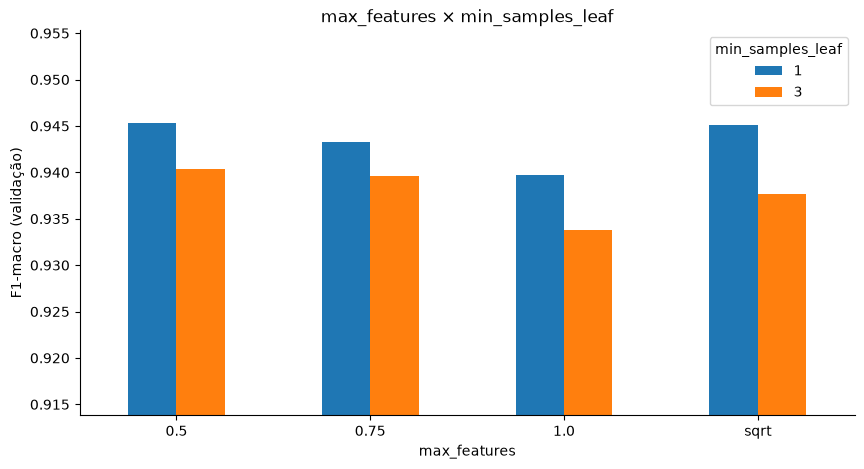

In [36]:
busca_rf = GridSearchCV(RandomForestClassifier(n_jobs=-1, random_state=RANDOM_STATE),
                        param_grid={'max_features': ['sqrt', 0.5, 0.75, 1.0],
                                    'min_samples_leaf': [1, 3]},
                        scoring='f1_macro', cv=divisao_val, return_train_score=True, refit=False)
inicio = time.time()
busca_rf.fit(engenharia(X_tv), y_tv)
print(f'Busca concluída em {time.time() - inicio:.0f}s')

cv_rf = pd.DataFrame(busca_rf.cv_results_)
cv_rf['max_features'] = cv_rf['param_max_features'].astype(str)
display(cv_rf[['max_features', 'param_min_samples_leaf', 'mean_train_score', 'mean_test_score', 'mean_fit_time']]
        .rename(columns={'param_min_samples_leaf': 'min_samples_leaf', 'mean_train_score': 'F1-macro treino',
                         'mean_test_score': 'F1-macro val', 'mean_fit_time': 'tempo (s)'})
        .sort_values('F1-macro val', ascending=False).round(4))
print('Melhores hiper-parâmetros:', busca_rf.best_params_)

pivo = cv_rf.pivot(index='max_features', columns='param_min_samples_leaf', values='mean_test_score')
ax = pivo.plot.bar(rot=0, ylim=(pivo.min().min() - 0.02, pivo.max().max() + 0.01))
ax.set_ylabel('F1-macro (validação)')
ax.set_title('max_features × min_samples_leaf')
ax.legend(title='min_samples_leaf')
plt.show()

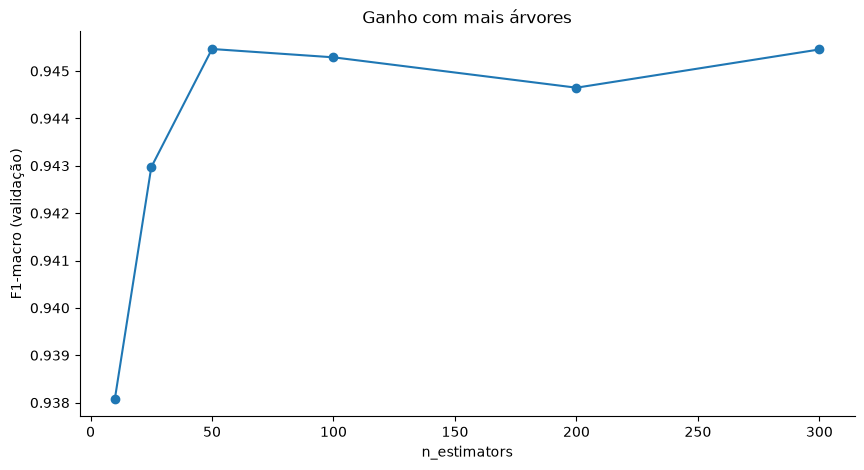

,n_estimators,F1-macro val
0,10,0.9381
1,25,0.9430
2,50,0.9455
3,100,0.9453
4,200,0.9446
5,300,0.9455


In [37]:
# n_estimators: com warm_start, as árvores são adicionadas ao mesmo modelo, sem re-treinar as anteriores
melhor_rf = busca_rf.best_params_
X_tr_fe, X_va_fe = engenharia(X_treino), engenharia(X_val)
rf_crescente = RandomForestClassifier(warm_start=True, n_jobs=-1, random_state=RANDOM_STATE, **melhor_rf)
curva_arvores = []
for n in [10, 25, 50, 100, 200, 300]:
    rf_crescente.set_params(n_estimators=n).fit(X_tr_fe, y_treino)
    curva_arvores.append((n, f1_score(y_val, rf_crescente.predict(X_va_fe), average='macro')))
del rf_crescente
curva_arvores = pd.DataFrame(curva_arvores, columns=['n_estimators', 'F1-macro val'])

fig, ax = plt.subplots()
ax.plot(curva_arvores['n_estimators'], curva_arvores['F1-macro val'], 'o-')
ax.set_xlabel('n_estimators')
ax.set_ylabel('F1-macro (validação)')
ax.set_title('Ganho com mais árvores')
plt.show()
display(curva_arvores.round(4))

,,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
método,versão,,,,,,,,
Random Forest,Tunado,1.0,0.971,1.0,0.9455,0.9385,18,96.8,0.0545


,acurácia treino,acurácia val,F1-macro treino,F1-macro val,bal. acc. val,nº features,tempo treino (s),gap F1 (treino - val)
versão,,,,,,,,
Baseline,1.0,0.9475,1.0,0.9168,0.8984,54,16.0,0.0832
V1a: one-hot compactado (12 feat.),1.0,0.9566,1.0,0.9284,0.9144,12,12.7,0.0716
V1b: compactado + engenharia,1.0,0.9706,1.0,0.9451,0.9364,18,17.3,0.0549
V1c: padronização + PCA (14 comp.),1.0,0.9278,1.0,0.8716,0.8424,14,20.4,0.1284
Tunado,1.0,0.9710,1.0,0.9455,0.9385,18,96.8,0.0545


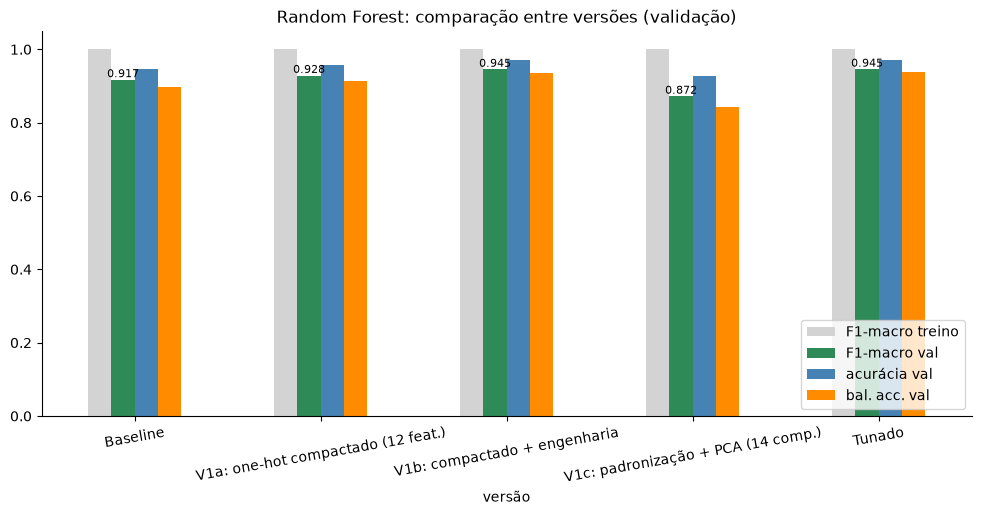

                   precision    recall  f1-score   support

       Spruce/Fir      0.976     0.967     0.971     42368
   Lodgepole Pine      0.971     0.980     0.976     56660
   Ponderosa Pine      0.959     0.973     0.966      7151
Cottonwood/Willow      0.901     0.882     0.891       549
            Aspen      0.927     0.868     0.897      1899
      Douglas-fir      0.957     0.935     0.946      3474
        Krummholz      0.978     0.964     0.971      4102

         accuracy                          0.971    116203
        macro avg      0.953     0.938     0.945    116203
     weighted avg      0.971     0.971     0.971    116203



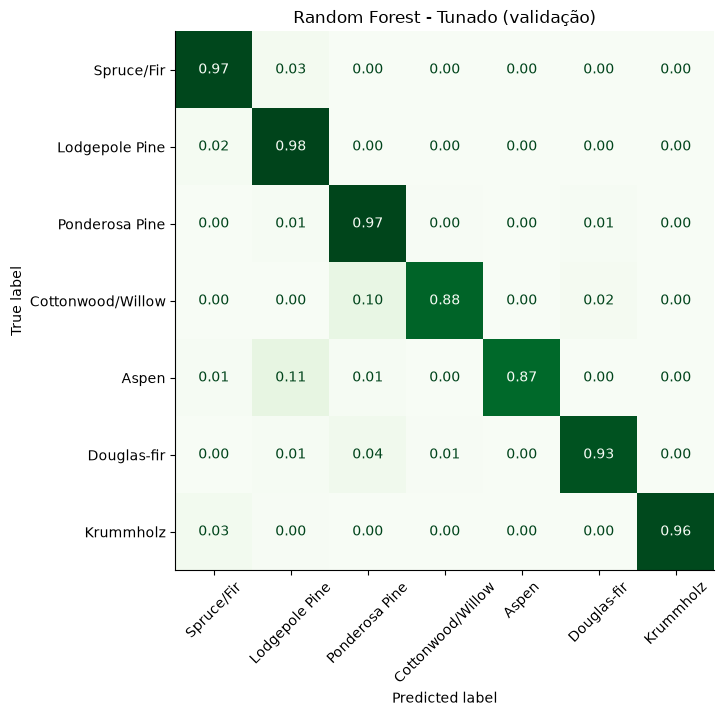

In [38]:
rf_tunado, p_val = avaliar('Random Forest', 'Tunado',
                           RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE, **melhor_rf),
                           preparar=engenharia)
del rf_tunado
comparar('Random Forest')
relatorio(y_val, p_val, 'Random Forest - Tunado (validação)')

**Análise do tunning:**
- **`max_features = 0,5`** (9 das 18 features sorteadas por divisão) foi o melhor valor, mas por muito pouco: 0,9453 contra 0,9451 do padrão `sqrt`, com o dobro do tempo de treino.
- **`min_samples_leaf = 3`** piora em todas as combinações. Folhas maiores regularizam, mas prejudicam as classes raras, que dependem de regiões pequenas do espaço.
- **`n_estimators`:** o ganho vai até cerca de 50 árvores e depois fica num platô, com oscilação só na 4ª casa decimal. Usei 300 para estabilidade, sabendo que o ganho é marginal.
- **Resultado:** F1-macro de validação **0,9455**, contra 0,9451 da V1b. O ganho é praticamente nulo. Os parâmetros padrão do Random Forest já estavam perto do ótimo para esta base. **Os ganhos vieram dos dados (Versão 1), não dos hiper-parâmetros.** O tunning serve para confirmar que não há configuração claramente melhor e que o modelo é estável.
- **Custo:** cerca de 5x mais tempo de treino que a V1b.

**Diagnóstico de overfitting e underfitting do modelo final**

Duas técnicas complementares, aplicadas no conjunto treino + validação (o teste continua intocado):
- **Validação cruzada estratificada (5 folds):** o modelo é treinado e avaliado 5 vezes, cada vez com uma parte diferente dos dados como validação. A média ± desvio mostra se o resultado é **estável** ou se dependeu da divisão escolhida, e o gap treino × validação aparece em cada fold.
- **Curva de aprendizado:** F1-macro no treino e na validação conforme aumenta a quantidade de dados de treino. Curvas **juntas e baixas** indicam **underfitting** (mais dados não ajudam). Curvas **separadas**, com a validação subindo, indicam **variância/overfitting** (mais dados ajudam).

Diagnóstico concluído em 709s


,F1-macro treino,F1-macro val,acurácia treino,acurácia val,gap F1 (treino - val)
fold 1,1.0,0.9501,1.0,0.9730,0.0499
fold 2,1.0,0.9484,1.0,0.9742,0.0516
fold 3,1.0,0.9497,1.0,0.9743,0.0503
fold 4,1.0,0.9500,1.0,0.9731,0.0500
fold 5,1.0,0.9527,1.0,0.9739,0.0473
média,1.0,0.9502,1.0,0.9737,0.0498
desvio,0.0,0.0016,0.0,0.0006,0.0016


Validação cruzada: F1-macro = 0.9502 ± 0.0016 | acurácia = 0.9737 ± 0.0006


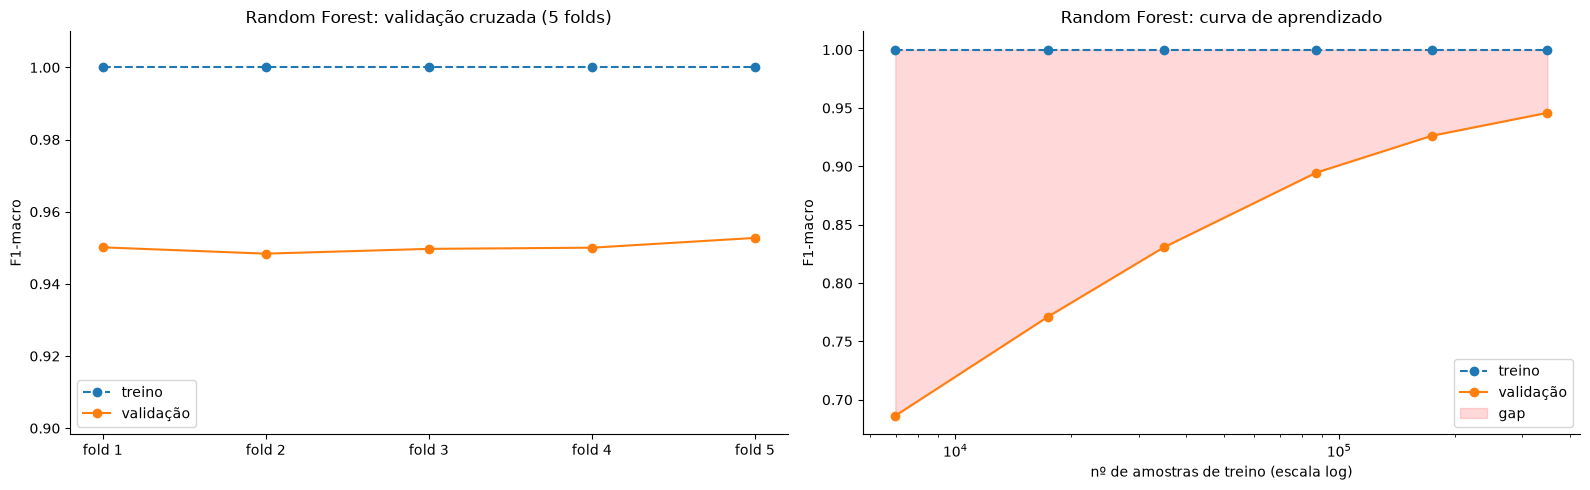

,amostras de treino,F1-macro treino,F1-macro val
0,6972,1.0,0.6863
1,17430,1.0,0.7712
2,34860,1.0,0.8305
3,87151,1.0,0.8946
4,174303,1.0,0.9262
5,348606,1.0,0.9459


In [39]:
diagnosticar('Random Forest',
             RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE, **melhor_rf),
             preparar=engenharia)

**Análise do diagnóstico:**
- **Validação cruzada:** F1-macro de **0,950 ± 0,002** e acurácia de **97,4% ± 0,06%** nos 5 folds. O resultado é **estável**. O F1 é um pouco maior que o da validação única (0,946) porque, na validação cruzada, cada modelo treina com 372 mil amostras em vez de 349 mil. A curva de aprendizado explica essa diferença.
- **Gap treino × validação:** fica em ~0,05 em todos os folds. O treino é sempre 1,0, porque as árvores memorizam os dados.
- **Curva de aprendizado:** a validação **sobe continuamente**, de 0,686 (7 mil amostras) para 0,946 (349 mil), sem atingir um platô. O gap cai de 0,31 para 0,05. É o perfil de um modelo de **alta variância que ainda se beneficia de mais dados**. Esse overfitting não é prejudicial: a validação é alta e continua melhorando, e o *ensemble* mantém a generalização. Mais dados tendem a melhorar ainda mais o resultado.

### 4) **(10%)** Conclusões

#### 4.1) Avaliação final no conjunto de teste

Até aqui todas as decisões foram tomadas com a validação. Agora uso as predições no **teste** (dados nunca vistos em nenhuma escolha) para a estimativa final de cada versão.

In [40]:
final = []
for (metodo, versao), pred in predicoes_teste.items():
    final.append({'método': metodo, 'versão': versao,
                  'acurácia teste': accuracy_score(y_teste, pred),
                  'F1-macro teste': f1_score(y_teste, pred, average='macro'),
                  'bal. acc. teste': balanced_accuracy_score(y_teste, pred)})
final = pd.DataFrame(final).set_index(['método', 'versão'])
validacao = pd.DataFrame(resultados).set_index(['método', 'versão'])[['F1-macro treino', 'F1-macro val', 'tempo treino (s)']]
tabela_final = validacao.join(final)
display(tabela_final.round(4))

F1-macro treino  F1-macro val  tempo treino (s)  acurácia teste  F1-macro teste  bal. acc. teste
método              versão                                                                                                                              
Regressão Logística Baseline                                     0.2358        0.2354              10.5          0.6201          0.2348           0.2325
                    V1a: padronização                            0.5333        0.5325              20.0          0.7235          0.5310           0.5099
                    V1b: padronização + PCA (14 comp.)           0.4699        0.4707              10.9          0.7074          0.4644           0.4371
                    V1c: padronização + polinomial               0.6298        0.6297              80.1          0.7405          0.6238           0.5913
                    Tunado                                       0.6400        0.6387             110.2          0.7413          0.6374           0.6080
Random Forest       Baseline                                     1.0000        0.9168              16.0          0.9482          0.9163           0.8974
                    V1a: one-hot compactado (12 feat.)           1.0000        0.9284              12.7          0.9564          0.9260           0.9096
                    V1b: compactado + engenharia                 1.0000        0.9451              17.3          0.9705          0.9458           0.9361
                    V1c: padronização + PCA (14 comp.)           1.0000        0.8716              20.4          0.9286          0.8708           0.8386
                    Tunado                                       1.0000        0.9455              96.8          0.9712          0.9480           0.9403

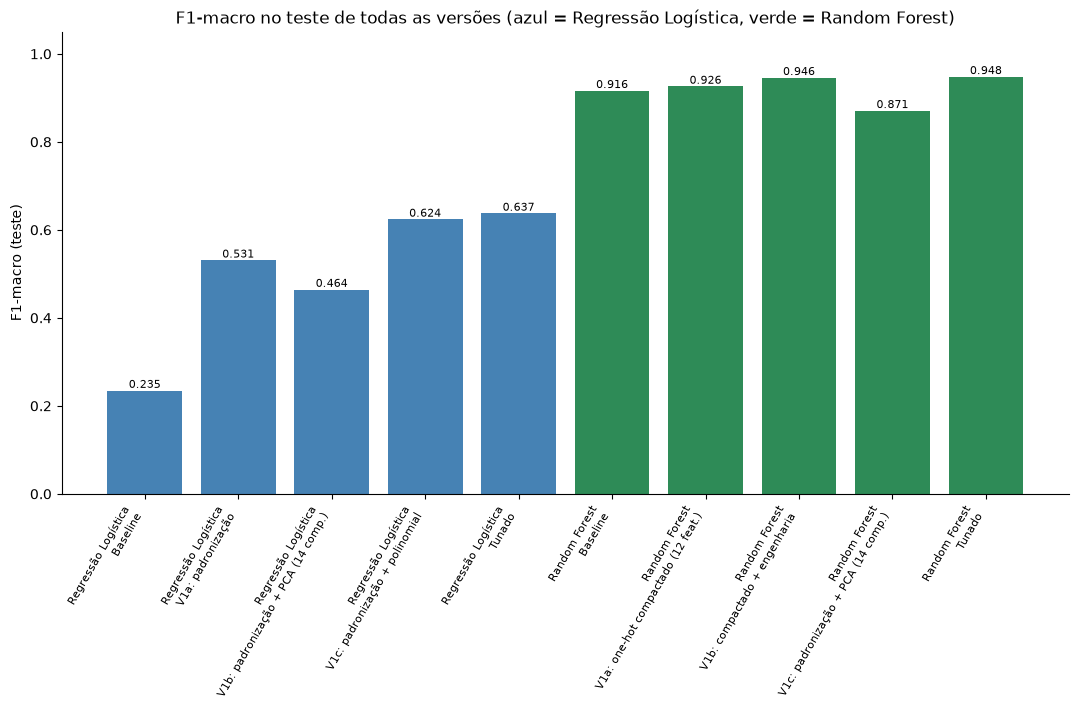

In [41]:
fig, ax = plt.subplots(figsize=(13, 6))
rotulos = [f'{m}\n{v}' for m, v in tabela_final.index]
cores = ['steelblue' if m == 'Regressão Logística' else 'seagreen' for m, _ in tabela_final.index]
barras = ax.bar(range(len(tabela_final)), tabela_final['F1-macro teste'], color=cores)
ax.bar_label(barras, fmt='%.3f', fontsize=8)
ax.set_xticks(range(len(tabela_final)), rotulos, rotation=60, ha='right', fontsize=8)
ax.set_ylabel('F1-macro (teste)')
ax.set_ylim(0, 1.05)
ax.set_title('F1-macro no teste de todas as versões (azul = Regressão Logística, verde = Random Forest)')
plt.show()

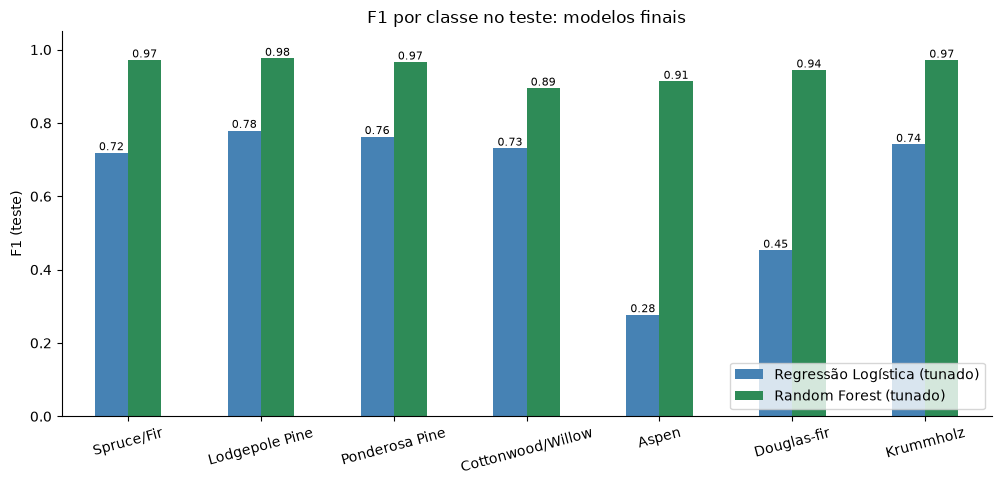

In [42]:
# F1 por classe dos dois modelos finais
f1_classes = pd.DataFrame({
    'Regressão Logística (tunado)': f1_score(y_teste, predicoes_teste[('Regressão Logística', 'Tunado')], average=None),
    'Random Forest (tunado)': f1_score(y_teste, predicoes_teste[('Random Forest', 'Tunado')], average=None),
}, index=ROTULOS)
ax = f1_classes.plot.bar(figsize=(12, 5), rot=15, color=['steelblue', 'seagreen'], ylim=(0, 1.05))
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', fontsize=8)
ax.set_ylabel('F1 (teste)')
ax.set_title('F1 por classe no teste: modelos finais')
ax.legend(loc='lower right')
plt.show()

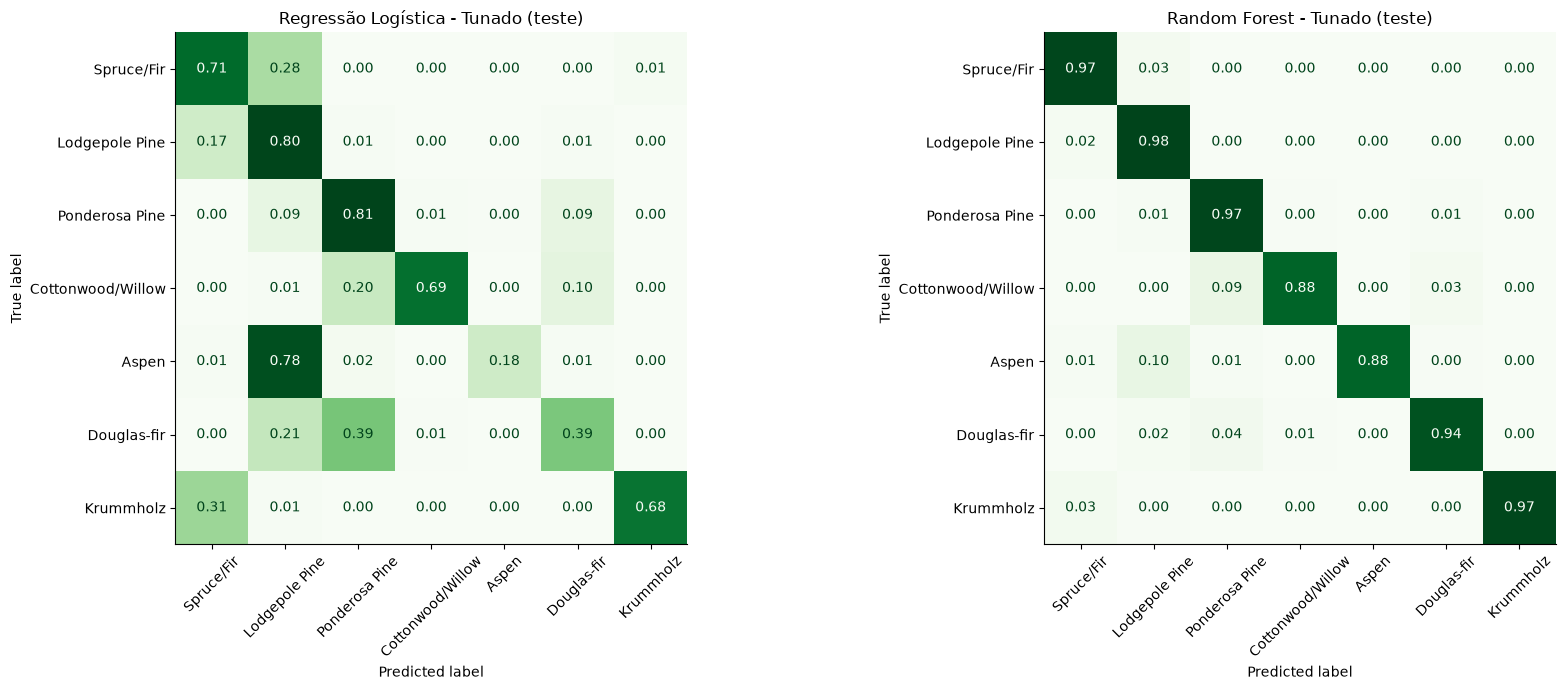

In [43]:
fig, eixos = plt.subplots(1, 2, figsize=(18, 7))
for ax, metodo in zip(eixos, ['Regressão Logística', 'Random Forest']):
    ConfusionMatrixDisplay.from_predictions(y_teste, predicoes_teste[(metodo, 'Tunado')], normalize='true',
                                            display_labels=ROTULOS, values_format='.2f', cmap='Greens',
                                            colorbar=False, xticks_rotation=45, ax=ax)
    ax.set_title(f'{metodo} - Tunado (teste)')
plt.tight_layout()
plt.show()

#### 4.2) Respostas

**Comparação dos resultados (teste):**

| Modelo | Acurácia | F1-macro | Balanced acc. |
|---|---|---|---|
| Regressão Logística: Baseline | 62,0% | 0,235 | 0,233 |
| Regressão Logística: Tunado | 74,1% | 0,637 | 0,608 |
| Random Forest: Baseline | 94,8% | 0,916 | 0,897 |
| Random Forest: Tunado | **97,1%** | **0,948** | **0,940** |

- Em todas as versões, as métricas no teste ficaram praticamente iguais às da validação (diferenças abaixo de 0,01). As escolhas feitas na validação generalizam, e não houve overfitting na seleção de modelos.
- A **validação cruzada estratificada de 5 folds** confirma os números com desvios muito pequenos: F1-macro de **0,636 ± 0,002** na Regressão Logística e de **0,950 ± 0,002** no Random Forest. Os resultados não dependem da divisão escolhida.
- As **curvas de aprendizado** mostram diagnósticos opostos. A Regressão Logística está em **underfitting**: as curvas se encontram em ~0,64 e mais dados não ajudam. O Random Forest tem **alta variância, mas continua melhorando** com mais dados.
- A Regressão Logística depende muito de pré-processamento (padronização + features polinomiais: F1 de 0,235 para 0,637), mas para em cerca de 74% de acurácia porque é um modelo linear, em **underfitting** em todas as versões.
- O Random Forest começa muito acima. Os seus ganhos vieram da **representação dos dados** (compactação do one-hot e engenharia de features), e o tunning de hiper-parâmetros acrescentou pouco.
- Nos dois métodos, o **PCA piorou o resultado**. A redução de dimensionalidade que funcionou foi a guiada pelo conhecimento da base (desfazer o one-hot: 54 → 12 features).

**Qual eu escolheria para produção? O Random Forest tunado.**
- O F1-macro é 0,948, contra 0,637. A maior diferença está nas classes raras: Aspen tem F1 0,91 contra 0,28, e Douglas-fir tem 0,94 contra 0,45. Num problema desbalanceado, são essas classes que distinguem um bom modelo.
- O desempenho é estável entre validação e teste.
- Se custo de treino, memória ou latência pesarem mais, a **V1b** (100 árvores, parâmetros padrão) entrega praticamente o mesmo resultado (F1 0,946) com 1/5 do tempo de treino.

**Riscos:**
1. **Estimativa possivelmente otimista.** A divisão foi aleatória, mas as amostras são células vizinhas de terreno, que se parecem muito. Treino e teste podem ter "quase as mesmas" células. Numa região nova, o desempenho tende a ser menor.
2. **Mudança na distribuição dos dados (*data drift*).** Os dados vêm de uma única floresta no Colorado. Outra região, mudanças climáticas, incêndios ou desmatamento alteram a relação entre as features e a cobertura. Parte do que o modelo aprendeu é a "geografia" desta floresta (Cottonwood/Willow, por exemplo, só existe em Cache la Poudre).
3. **Classes raras.** Cottonwood/Willow e Aspen continuam sendo as de menor F1. Se o uso for, por exemplo, a conservação de uma espécie rara, esses erros custam mais do que os outros.
4. **Custo e interpretabilidade.** São 300 árvores profundas, da ordem de 1 GB em memória, e as decisões são mais difíceis de explicar do que os coeficientes de uma Regressão Logística.

**Próximos passos:**
- **Mais dados**, se possível de outras regiões: a curva de aprendizado do Random Forest ainda não estabilizou.
- **Validação espacial** (separar treino e teste por regiões), para medir a generalização para áreas novas.
- Testar **modelos de *boosting*** (`HistGradientBoostingClassifier`, LightGBM, XGBoost) e **ExtraTrees**, que costumam ir bem em dados tabulares desse tipo.
- **Mais engenharia de features**: seno e cosseno de `Aspect` e interações entre altitude, solo e área selvagem.
- **Tratar as classes raras** com reamostragem (*oversampling*/SMOTE) ou com ajuste do limiar de decisão por classe.
- **Deixar o modelo mais leve** para produção: a curva de `n_estimators` mostra platô a partir de cerca de 50 árvores. Também vale monitorar *drift* depois da implantação.

# Bônus

### 6) Deep Learning: O dilema da "Caixa-Preta" (Desempenho vs. Explicabilidade)

**Enunciado:**
Modelos de Deep Learning (Aprendizado Profundo) utilizam redes neurais artificiais com múltiplas camadas ocultas capazes de identificar padrões extremamente complexos em grandes volumes de dados — superando, muitas vezes, a precisão humana em tarefas como diagnósticos médicos por imagem ou análise de crédito. No entanto, quanto mais profunda e precisa é uma rede neural, menor costuma ser a sua interpretabilidade (o chamado problema da "caixa-preta"), tornando difícil explicar exatamente como o modelo chegou a uma determinada decisão.

**Pergunta:**
Considerando o funcionamento das redes neurais profundas, explique por que ocorre essa dificuldade em rastrear o "raciocínio" do modelo e posicione-se: em áreas críticas como saúde, justiça ou concessão de crédito, devemos priorizar modelos de Deep Learning com maior taxa de acerto (mesmo sem saber explicar suas decisões) ou modelos mais simples e transparentes, porém menos precisos? Justifique sua opinião propondo pelo menos um critério ou limite para o uso dessas redes na sociedade.

**Resposta:**

**Por que é difícil rastrear o "raciocínio" do modelo**

Uma rede neural profunda não guarda regras do tipo "se renda < X, negar crédito". O que ela aprende fica espalhado em milhões (às vezes bilhões) de pesos. Cada camada aplica uma transformação não-linear sobre a saída da anterior, e a decisão final resulta da interação de todas essas transformações juntas. Nenhum peso isolado tem significado próprio. Um mesmo neurônio costuma participar de vários "conceitos" ao mesmo tempo, e um mesmo conceito fica distribuído entre muitos neurônios.

Além disso, o treinamento por gradiente só otimiza uma função de erro. Nada obriga a rede a aprender representações que façam sentido para um humano. Ela usa qualquer padrão estatístico que reduza o erro, inclusive atalhos indesejados, como reconhecer o hospital de origem de uma radiografia em vez da doença.

Existem técnicas de explicação *a posteriori* (SHAP, LIME, mapas de saliência), mas elas são aproximações locais do comportamento do modelo e não uma descrição fiel do que acontece dentro dele.

Vi uma versão menor desse dilema neste próprio projeto. A Regressão Logística (74% de acurácia) permite ler o peso de cada feature diretamente. O Random Forest (97%) é muito mais preciso, mas a decisão sai de 300 árvores profundas, e só consigo explicá-la de forma agregada, pela importância das features.

**Minha posição**

Em áreas críticas, acredito que a transparência deve ser o padrão, e o Deep Learning deve ser a exceção justificada. O motivo é que, em saúde, justiça e crédito, a decisão afeta direitos de uma pessoa específica. Essa pessoa precisa poder entender e **contestar** o resultado. A LGPD (art. 20) já garante o direito de pedir revisão de decisões tomadas unicamente por tratamento automatizado. O AI Act europeu classifica crédito e justiça como aplicações de alto risco, com exigência de supervisão humana.

Isso não significa proibir. Proponho como critério a **proporcionalidade entre impacto e explicabilidade**:

1. **Quanto mais grave e irreversível for o efeito sobre o indivíduo, maior a exigência de explicação.** Prisão ou negação de tratamento exige muito; recomendação de filme não exige quase nada.
2. **Modelos caixa-preta podem apoiar a decisão, mas não decidir sozinhos.** Por exemplo, um modelo que faz a triagem de exames cujo laudo final é do médico.
3. **O ganho de desempenho precisa ser grande e comprovado** em validação externa, e não apenas no conjunto de teste. Ele também precisa vir acompanhado de auditoria de vieses entre grupos (gênero, raça, renda).

Se um modelo simples chega perto do complexo, como acontece em muitos problemas de dados tabulares, a escolha deve ser o modelo simples.

### 7) IA Generativa: Criação, Autoria e os Limites da "Compreensão"

**Enunciado:**
Diferente da IA tradicional — voltada a classificar dados ou fazer previsões —, a IA Generativa (como Grandes Modelos de Linguagem e geradores de imagem) é capaz de produzir textos inéditos, códigos de programação, músicas e obras visuais a partir de padrões estatísticos aprendidos em bases de dados gigantescas. Por outro lado, esses modelos não possuem consciência ou vivência de mundo: eles operam prevendo o próximo elemento mais provável (tokens ou pixels) e estão sujeitos a fenômenos como as "alucinações" (geração de informações falsas com aparência convincente).

**Pergunta:**
A partir do modo como os modelos generativos são treinados e geram conteúdo, você considera que a IA Generativa é realmente capaz de ser "criativa" ou ela realiza apenas uma recombinação sofisticada do conhecimento humano já existente? Em sua resposta, explique como o funcionamento probabilístico desses modelos sustenta o seu ponto de vista e discuta como isso deve impactar o trabalho intelectual e artístico humano nos próximos anos.

**Resposta:**

**Como o modelo gera conteúdo**

Um modelo de linguagem é treinado para prever o próximo *token* a partir dos anteriores, ajustando seus parâmetros para imitar a distribuição estatística de um corpus gigantesco. Na geração, ele **amostra** dessa distribuição palavra por palavra, com um grau de aleatoriedade controlado pela temperatura. O resultado pode ser uma frase que nunca existiu, mas que é estatisticamente plausível dentro do que o modelo aprendeu.

As alucinações mostram bem esse limite: o modelo otimiza **plausibilidade**, não **verdade**. Ele não tem acesso ao mundo para verificar o que diz.

**Minha posição**

Para mim, a IA generativa é criativa em um sentido limitado. Uso a classificação da pesquisadora Margaret Boden, que separa três tipos de criatividade:

- **Combinatória:** juntar ideias conhecidas de jeitos novos.
- **Exploratória:** explorar as possibilidades dentro de um estilo ou regra.
- **Transformacional:** mudar as próprias regras, como o cubismo mudou a pintura.

Os modelos atuais são muito bons nas duas primeiras. Como tudo o que geram vem da distribuição aprendida, tendem ao "centro" dessa distribuição e têm dificuldade com a terceira.

É verdade que a criatividade humana também recombina referências. Para mim, a diferença está em três coisas que o modelo não tem: **intenção** (querer dizer algo), **vivência** (ter algo a dizer a partir da própria experiência) e **julgamento** (saber, diante do mundo real, se o resultado vale a pena). Hoje, quem escolhe, descarta e assina é o humano. Isso conversa com a lei brasileira de direitos autorais (Lei 9.610/98, art. 11), que define autor como a pessoa física criadora da obra.

**Impacto no trabalho intelectual e artístico**

- **Produção "média" vira commodity.** Texto padrão, ilustração genérica e código repetitivo tendem a perder valor de mercado, o que afeta diretamente ilustradores, redatores e tradutores.
- **O valor humano se desloca para curadoria, direção e verificação.** Saber pedir, avaliar, corrigir e dar uma visão original ganha importância.
- **Há riscos concretos.** As obras usadas no treino muitas vezes não tiveram consentimento ou remuneração. Existe ainda a homogeneização: se todos usam o mesmo modelo, a produção converge para o mesmo estilo. E a desinformação, já que o conteúdo é convincente mas não verificado.
- **Também há uma oportunidade.** Como ferramenta, a IA reduz barreiras de entrada e acelera protótipos, desde que o humano continue sendo o autor das decisões.